# Feedforward Neural Network (FFNN) Testing

13522029
13522043
13522093

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm.notebook import tqdm
from sklearn.neural_network import MLPClassifier

sys.path.append(os.path.abspath('..'))

from src.models.ffnn import FFNN
from src.models.activations import get_activation
from src.models.losses import get_loss
from src.models.initializers import get_initializer
from src.models.utils import (
    plot_training_history, plot_weight_distribution, 
    plot_network_graph, one_hot_encode, batch_iterator
)


Load dataset

In [ ]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, parser='auto')

# ensure correct data types
X = X.to_numpy().astype(np.float32)
y = y.to_numpy().astype(np.int32)

# Normalize pixel values to [0, 1]
X = X / 255.0

print(f"MNIST dataset loaded:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

MNIST dataset loaded:
X shape: (70000, 784)
y shape: (70000,)
Number of classes: 10


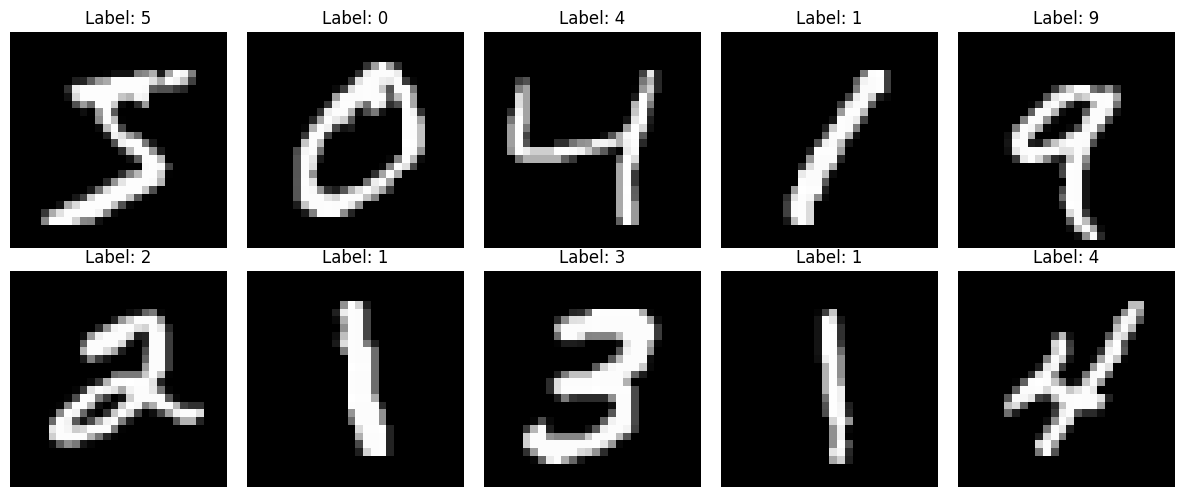

In [ ]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
n_samples = 100  # Berapa data
X_subset = X[:n_samples]
y_subset = y[:n_samples]

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42
)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# one hot encode multiclass class
y_train_one_hot = one_hot_encode(y_train)
y_test_one_hot = one_hot_encode(y_test)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
# print(f"One-hot encoded labels shape: {y_train_one_hot.shape}")

Training data shape: (80, 784)
Testing data shape: (20, 784)
One-hot encoded labels shape: (80, 10)


In [ ]:
def plot_comparison(histories, title="Model Comparison", metric="train_loss"):
    plt.figure(figsize=(12, 5))
    
    for name, history in histories.items():
        if metric in history and history[metric] is not None:
            plt.plot(history[metric], label=name)
    
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss" if "loss" in metric else "Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def evaluate_model(model, X_test, y_test, y_test_one_hot):
    y_pred = model.predict(X_test)
    
    if model.activations[-1].name() == "Softmax":
        y_pred_class = np.argmax(y_pred, axis=1)
    else:
        y_pred_class = np.round(y_pred).astype(int)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred_class)
    print(f"Test accuracy: {accuracy:.4f}")
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred_class)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (Accuracy: {accuracy:.4f})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    return accuracy

## Depth and Width Experiments

In [ ]:
# Parameter eksperimen
learning_rate = 0.01
batch_size = 64
epochs = 20  # increase / decrease sesuaikan (sekarang 20 utk eksperimen)

models = {}
histories = {}


--- Width Experiments ---

Training model with width=64


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.2991 - val_loss: 2.2998


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.2937 - val_loss: 2.2977


...

Epoch 18/20 - loss: 2.2227 - val_loss: 2.2879


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.2184 - val_loss: 2.2840


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.2143 - val_loss: 2.2828

Evaluation for width_narrow:
Test accuracy: 0.1000


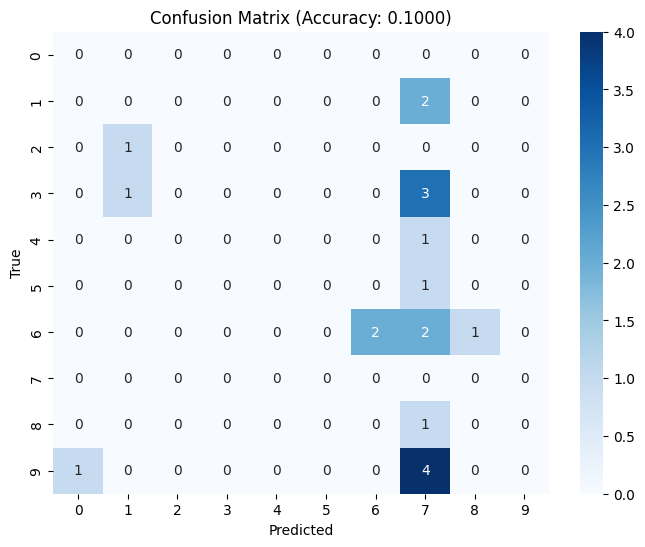


Weight distribution for width_narrow:


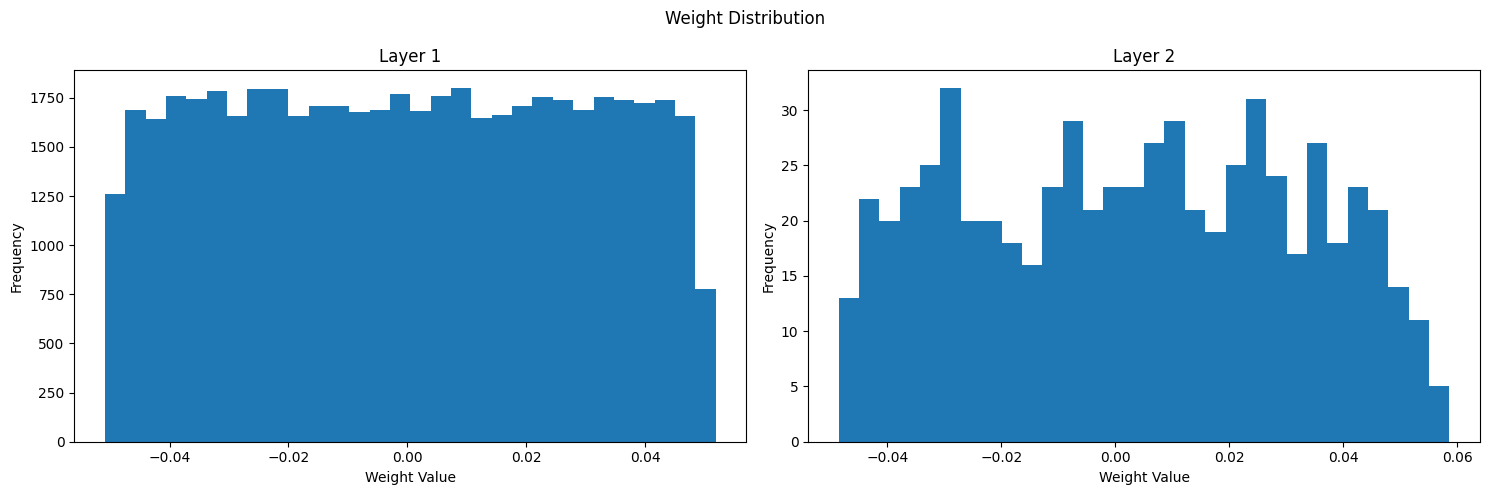


Gradient distribution for width_narrow:


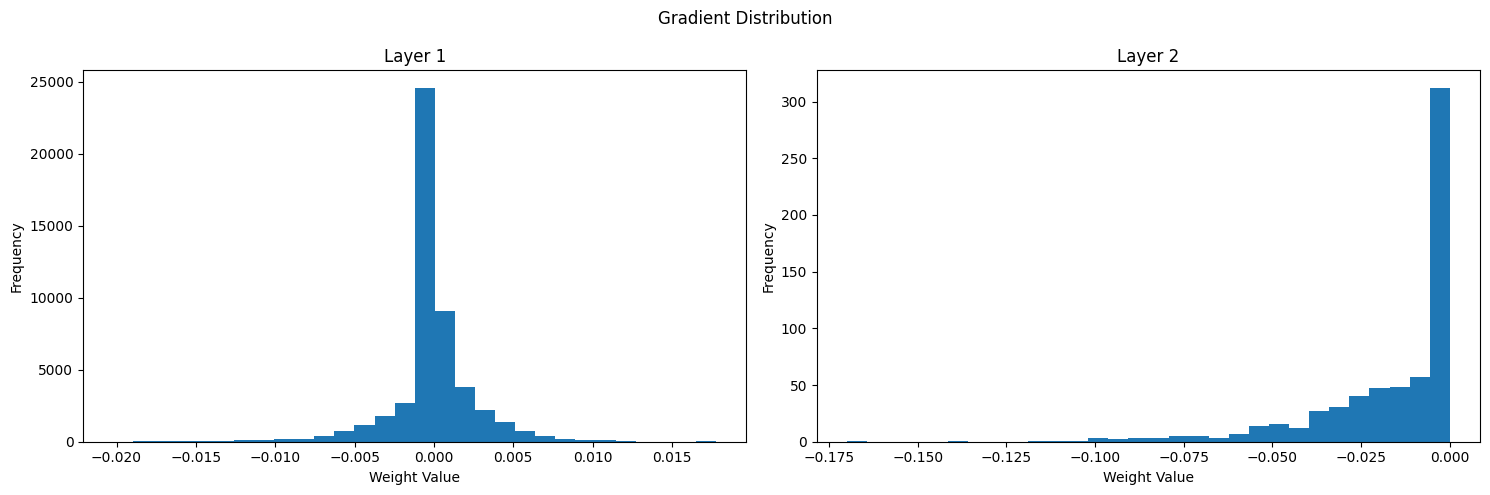


Training model with width=128


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.2855 - val_loss: 2.3216


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.2746 - val_loss: 2.3212


...

Epoch 18/20 - loss: 2.1323 - val_loss: 2.3059


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.1246 - val_loss: 2.3079


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.1158 - val_loss: 2.3025

Evaluation for width_medium:
Test accuracy: 0.1000


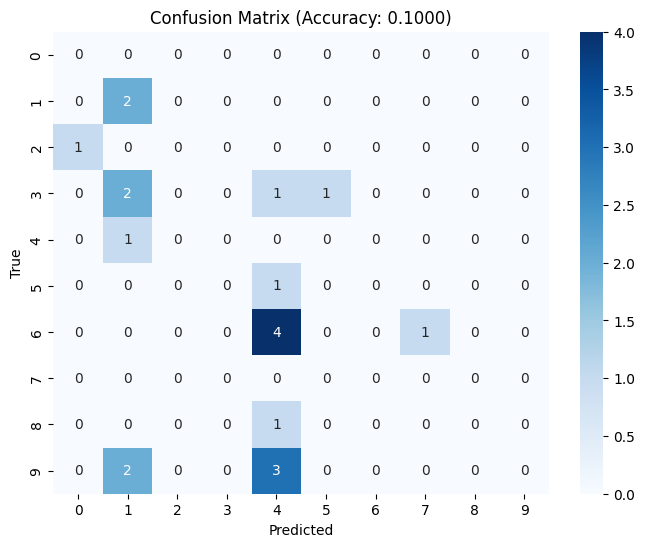


Weight distribution for width_medium:


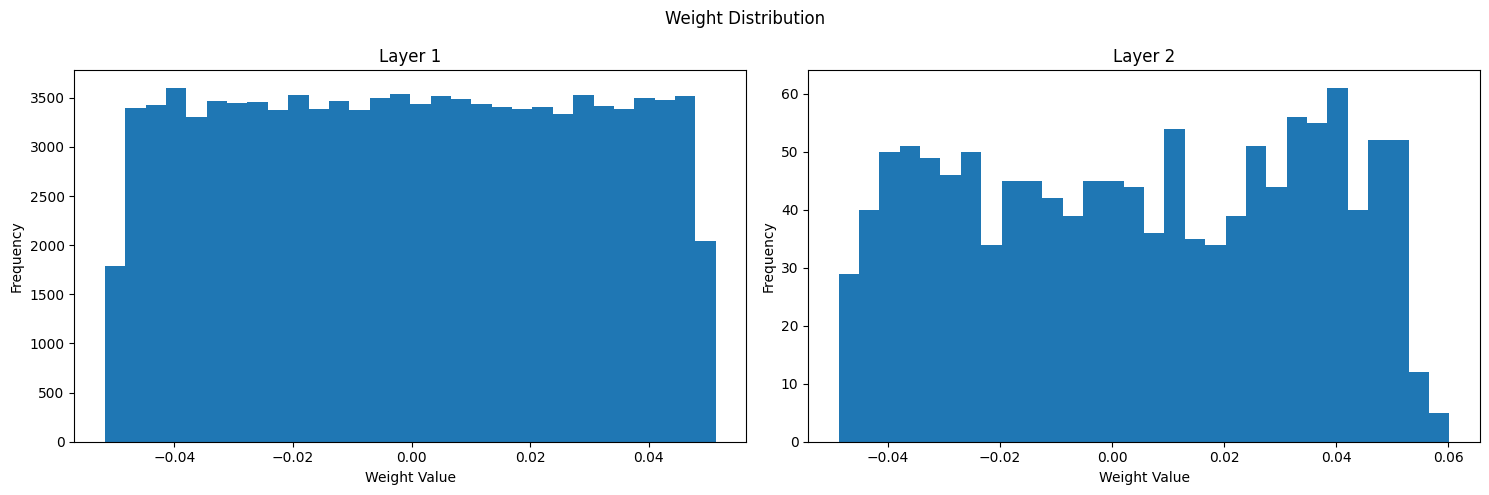


Gradient distribution for width_medium:


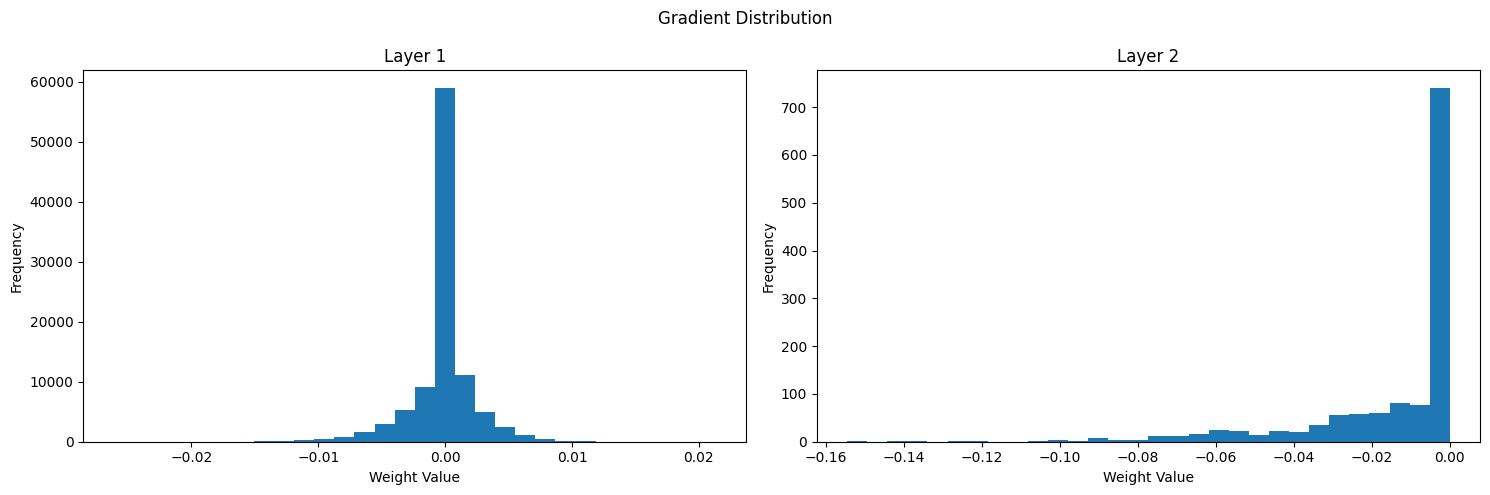


Training model with width=256


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.2921 - val_loss: 2.2846


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.2732 - val_loss: 2.2775


...

Epoch 18/20 - loss: 2.0139 - val_loss: 2.2019


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.0015 - val_loss: 2.2001


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 1.9875 - val_loss: 2.2036

Evaluation for width_wide:
Test accuracy: 0.3000


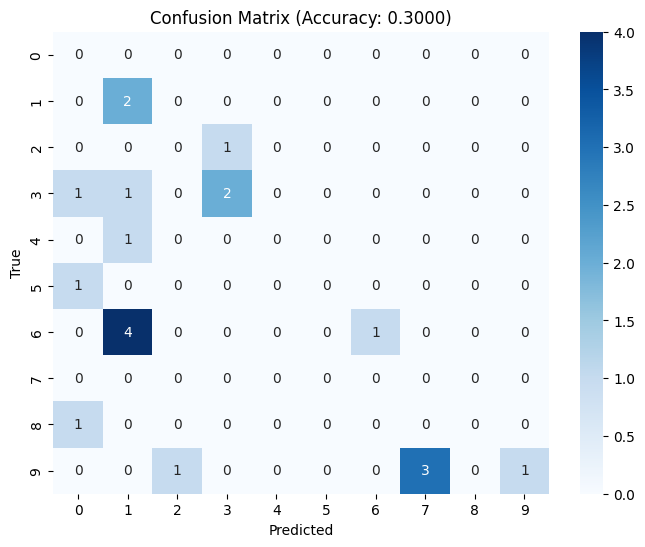


Weight distribution for width_wide:


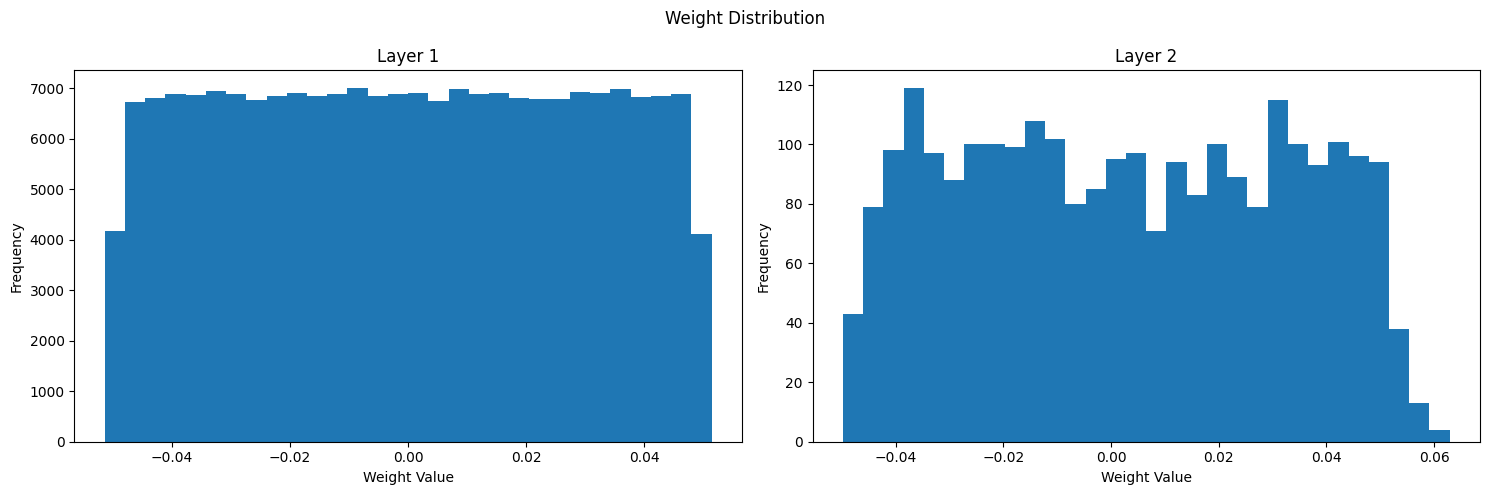


Gradient distribution for width_wide:


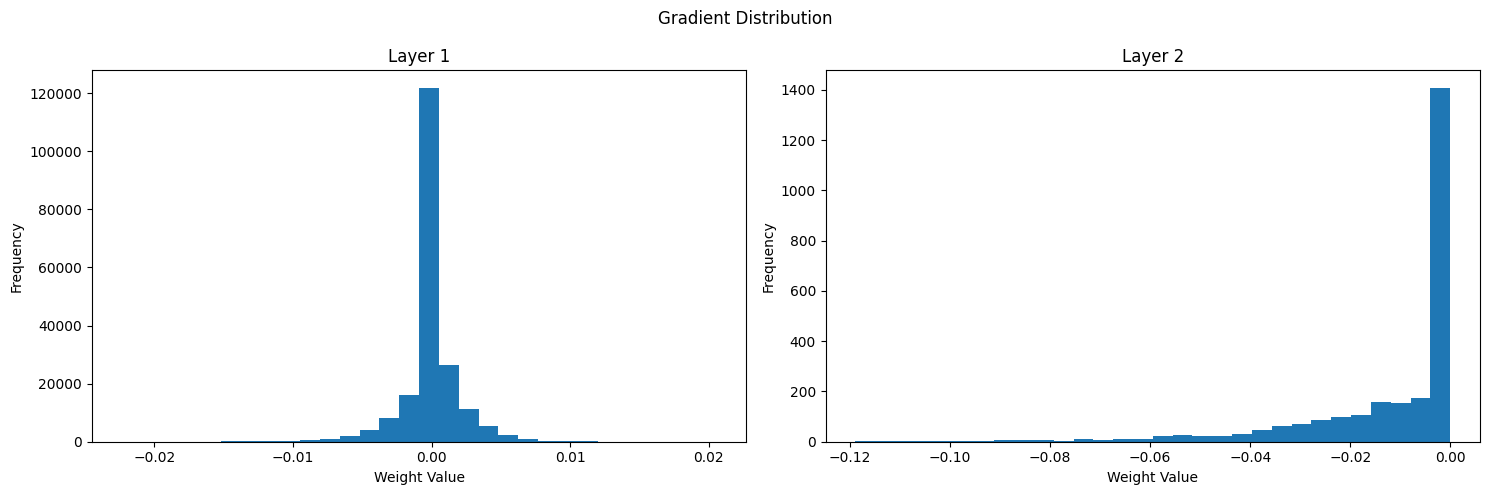

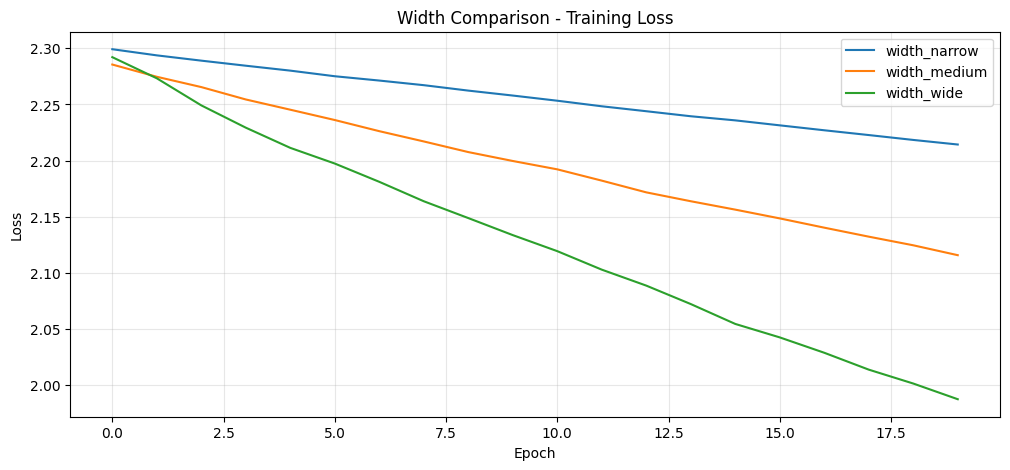

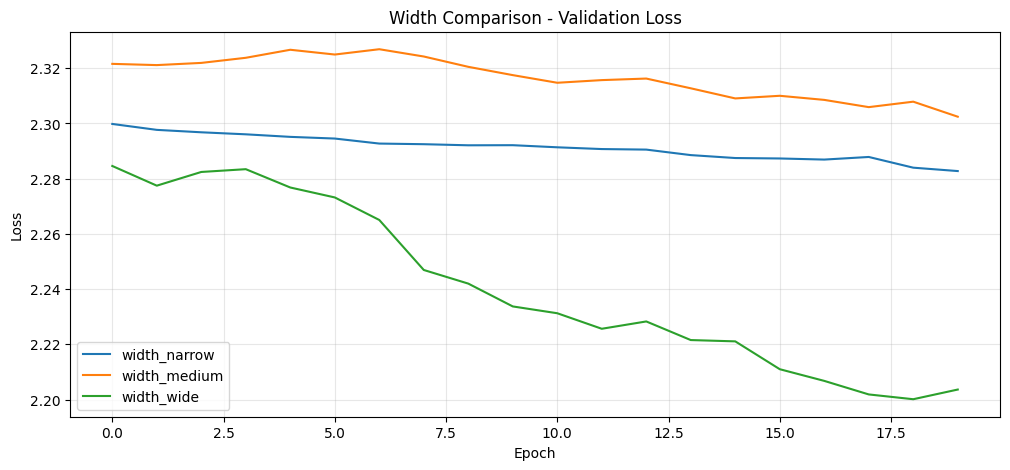

In [ ]:
# Width
width_variations = [
    {'name': 'narrow', 'hidden_units': 64},
    {'name': 'medium', 'hidden_units': 128},
    {'name': 'wide', 'hidden_units': 256}
]

print("\n--- Width Experiments ---")
for variation in width_variations:
    hidden_units = variation['hidden_units']
    name = f"width_{variation['name']}"
    
    layer_sizes = [784, hidden_units, 10]
    
    print(f"\nTraining model with width={hidden_units}")
    model = FFNN(
        layer_sizes=layer_sizes,
        activations=['relu', 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='uniform'
    )
    
    # progress bar tqdm
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        iterator = batch_iterator(X_train, y_train_one_hot, batch_size=batch_size)
        n_batches = int(np.ceil(len(X_train) / batch_size))
        
        for batch_idx, (X_batch, y_batch) in enumerate(tqdm(iterator, total=n_batches, 
                                                        desc=f'Epoch {epoch+1}/{epochs}')):
            # Forward and backward pass
            model.forward(X_batch)
            batch_loss = model.backward(y_batch)
            
            # Update weights
            model.update_weights(learning_rate)
            
            # Accumulate loss
            epoch_loss += batch_loss * len(X_batch) / len(X_train)
        
        history['train_loss'].append(epoch_loss)
        
        val_pred = model.forward(X_test)
        val_loss = model.loss.compute(y_test_one_hot, val_pred)
        history['val_loss'].append(val_loss)
        
        print(f'Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}')
    
    models[name] = model
    histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)

    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    # model.plot_weight()
    if has_nan_weights:
        print("cant plot weight distribution due to NaN values")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    # model.plot_gradient_distribution()
    if has_nan_gradients:
        print("ant plot gradient distribution due to NaN values")
    else:
        model.plot_gradient_distribution()

plot_comparison(histories, "Width Comparison - Training Loss", "train_loss")
plot_comparison(histories, "Width Comparison - Validation Loss", "val_loss")


--- Depth Experiments ---

Training model with depth=1 (hidden layers)


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3335 - val_loss: 2.2843


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.3235 - val_loss: 2.2824


...

Epoch 18/20 - loss: 2.1855 - val_loss: 2.2413


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.1767 - val_loss: 2.2397


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.1695 - val_loss: 2.2431

Evaluation for depth_shallow:
Test accuracy: 0.3500


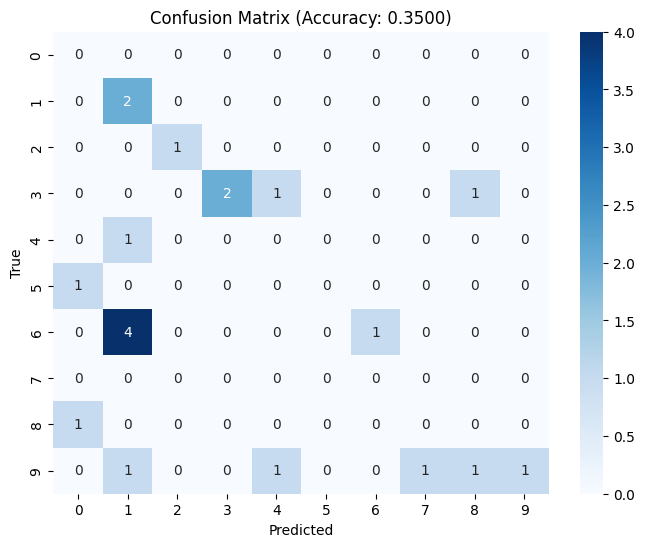


Weight distribution for depth_shallow:


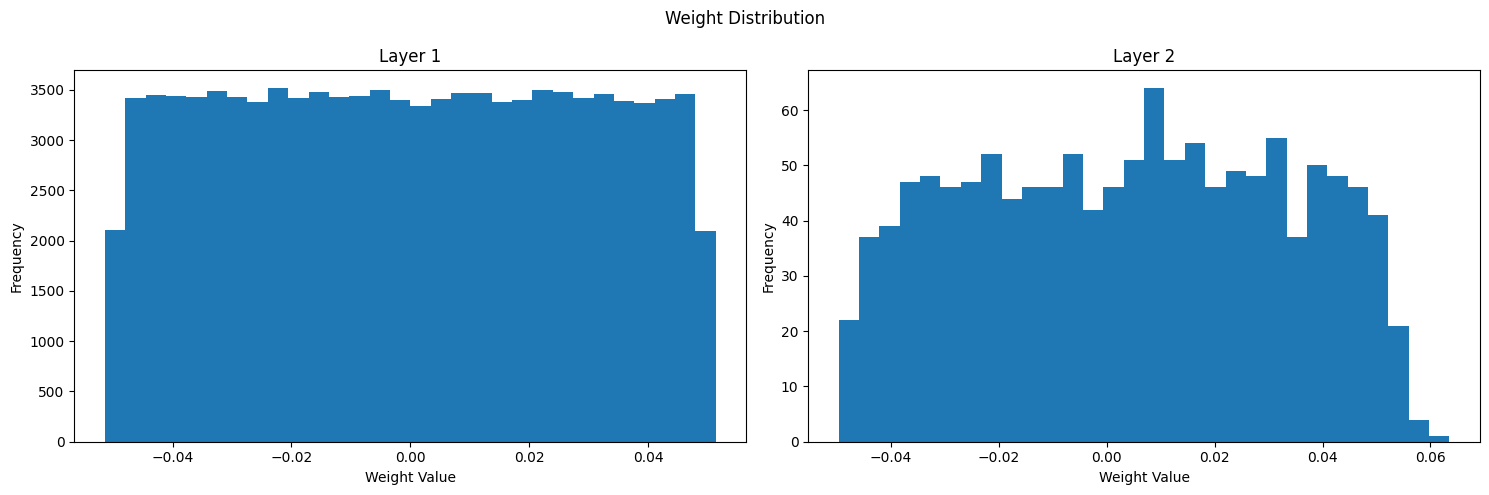


Gradient distribution for depth_shallow:


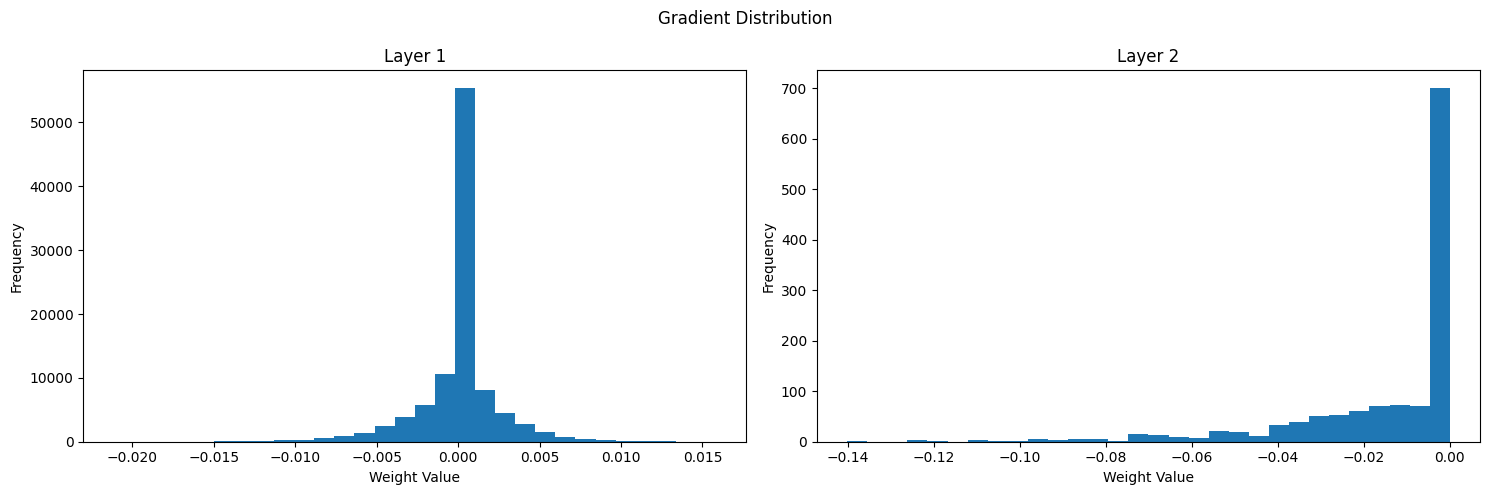


Training model with depth=2 (hidden layers)


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3065 - val_loss: 2.3087


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.3057 - val_loss: 2.3090


...

Epoch 18/20 - loss: 2.2939 - val_loss: 2.3120


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.2935 - val_loss: 2.3120


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.2928 - val_loss: 2.3115

Evaluation for depth_medium:
Test accuracy: 0.1000


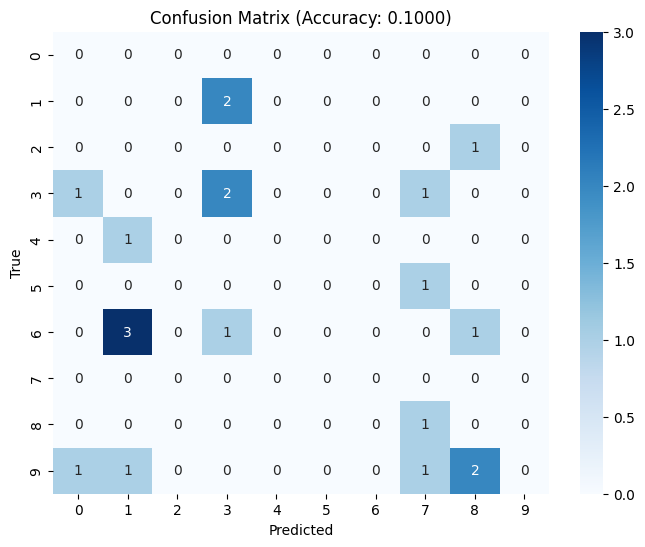


Weight distribution for depth_medium:


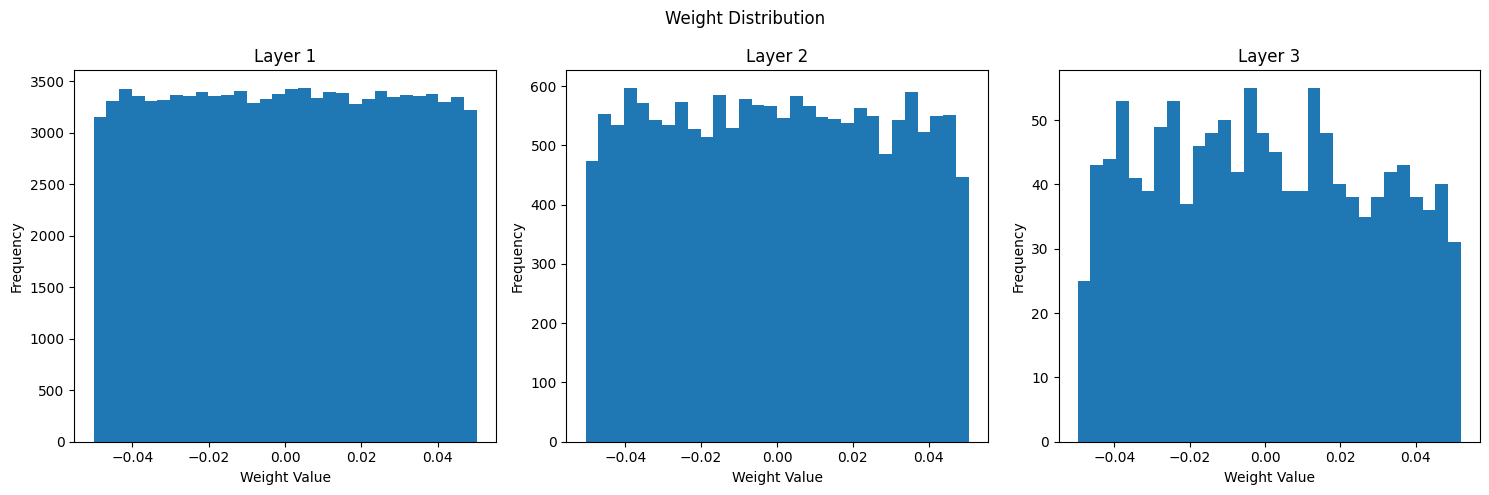


Gradient distribution for depth_medium:


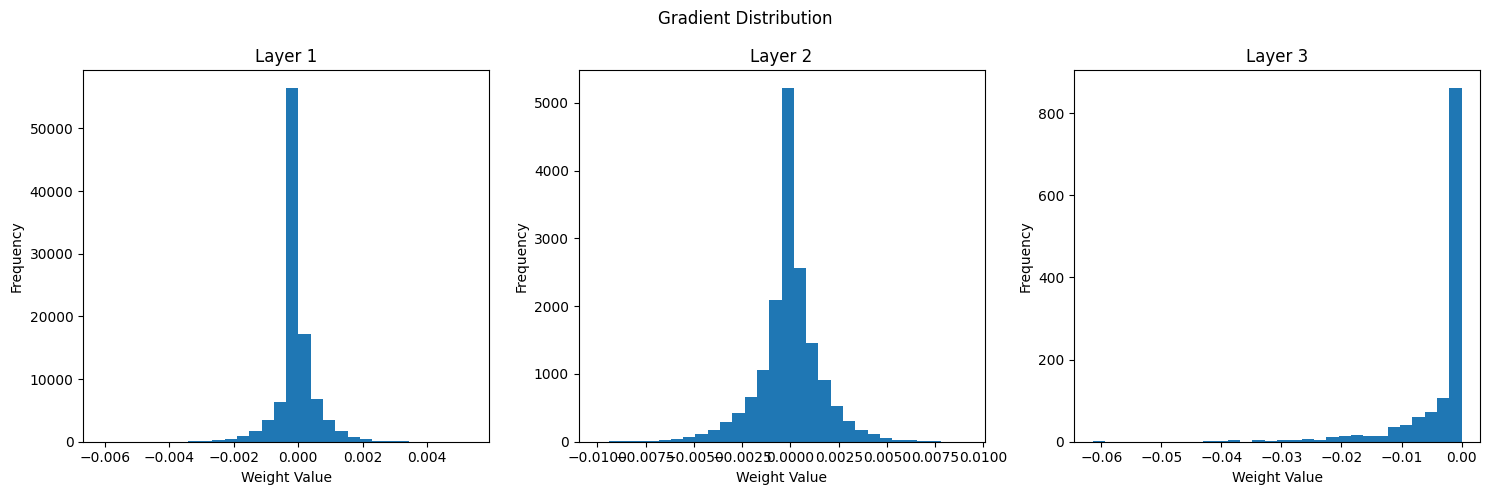


Training model with depth=3 (hidden layers)


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3033 - val_loss: 2.3020


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.3032 - val_loss: 2.3022


...

Epoch 18/20 - loss: 2.3008 - val_loss: 2.3044


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.3006 - val_loss: 2.3044


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.3005 - val_loss: 2.3048

Evaluation for depth_deep:
Test accuracy: 0.0500


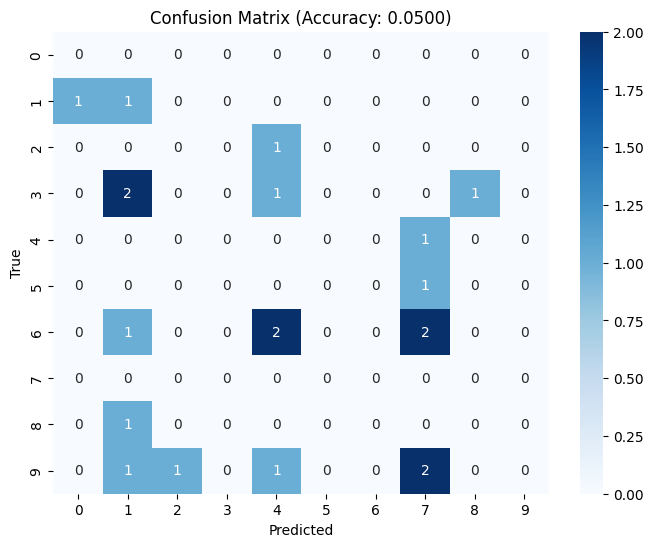


Weight distribution for depth_deep:


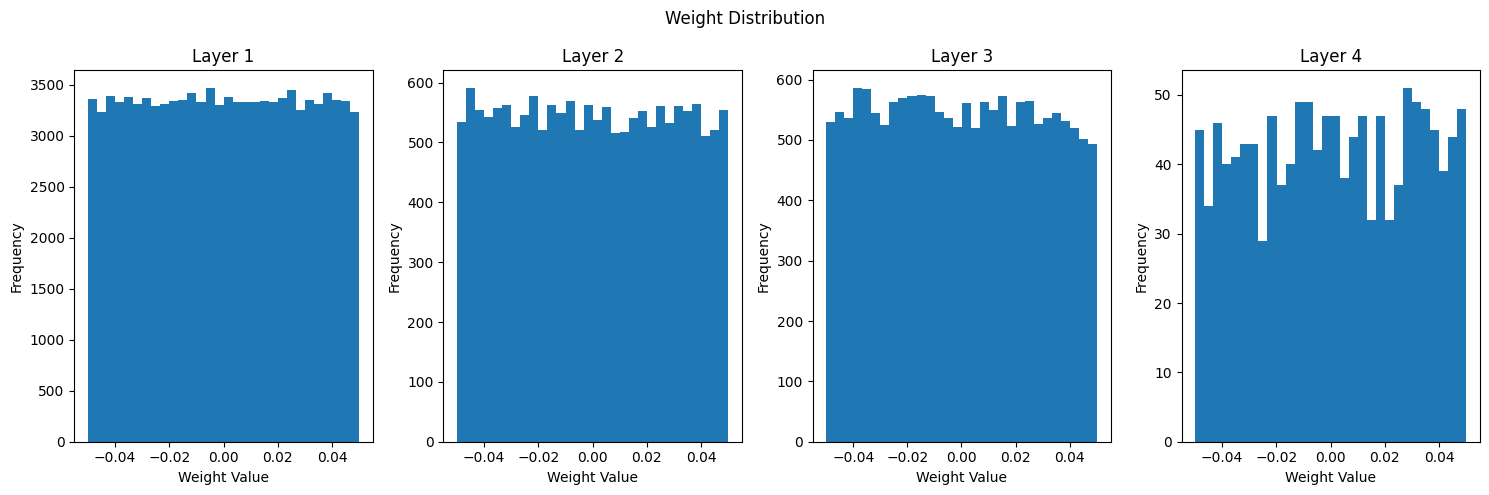


Gradient distribution for depth_deep:


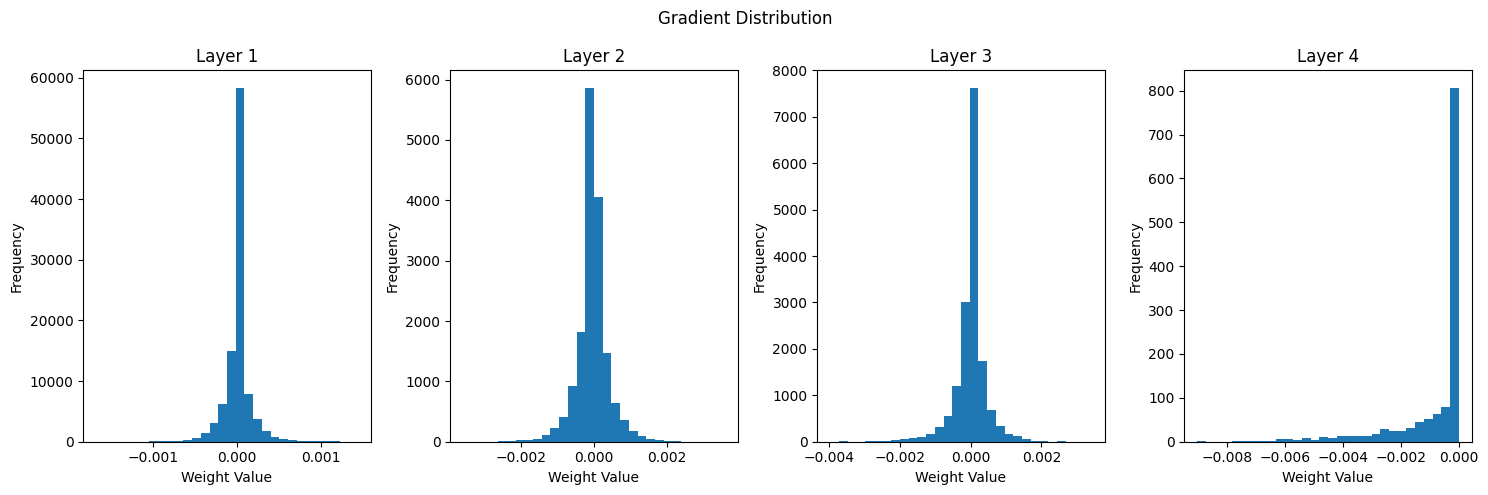

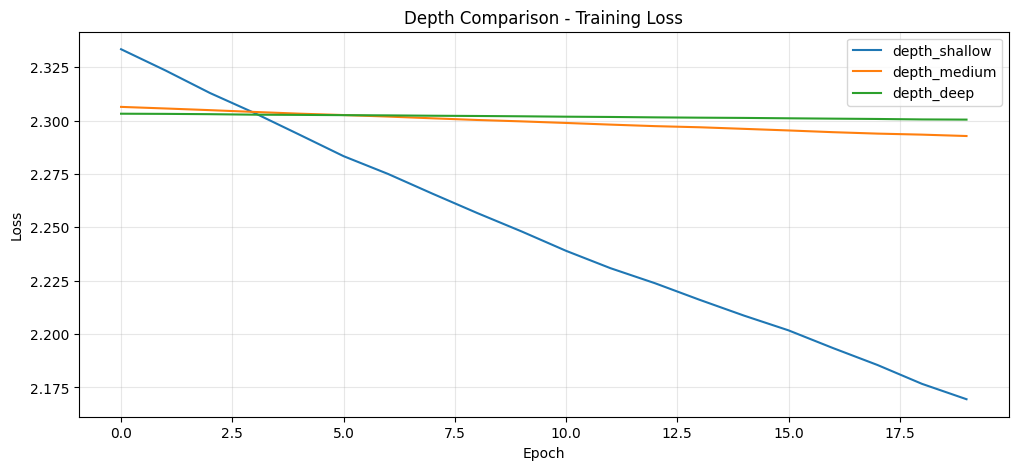

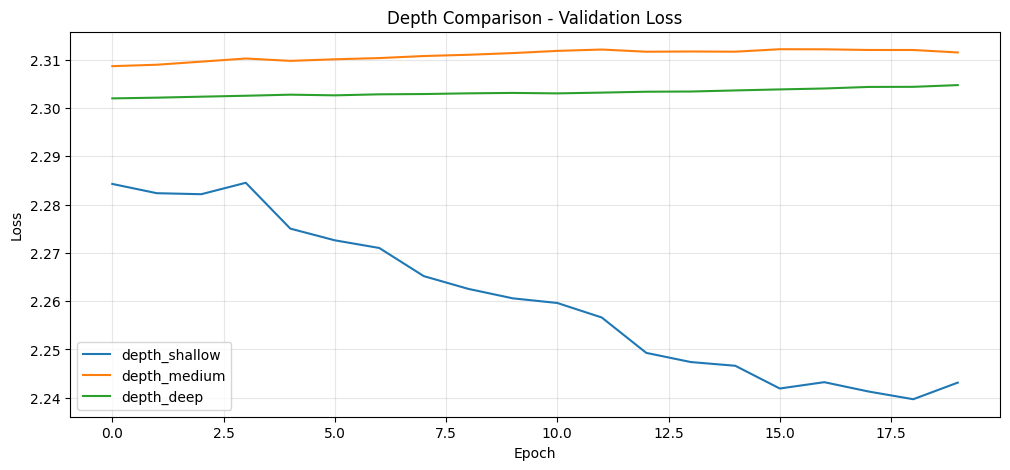

In [ ]:
# Depth
depth_variations = [
    {'name': 'shallow', 'n_layers': 1},
    {'name': 'medium', 'n_layers': 2},
    {'name': 'deep', 'n_layers': 3}
]

# Fixed width, cuma tes depth
fixed_width = 128

print("\n--- Depth Experiments ---")
for variation in depth_variations:
    n_layers = variation['n_layers']
    name = f"depth_{variation['name']}"
    
    layer_sizes = [784] + [fixed_width] * n_layers + [10]
    
    activations = ['relu'] * n_layers + ['softmax']
    
    print(f"\nTraining model with depth={n_layers} (hidden layers)")
    model = FFNN(
        layer_sizes=layer_sizes,
        activations=activations,
        loss='categorical_cross_entropy',
        weight_initializer='uniform'
    )
    
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        iterator = batch_iterator(X_train, y_train_one_hot, batch_size=batch_size)
        n_batches = int(np.ceil(len(X_train) / batch_size))
        
        for batch_idx, (X_batch, y_batch) in enumerate(tqdm(iterator, total=n_batches, 
                                                        desc=f'Epoch {epoch+1}/{epochs}')):
            # Forward and backward pass
            model.forward(X_batch)
            batch_loss = model.backward(y_batch)
            
            # Update weights
            model.update_weights(learning_rate)
            
            # Accumulate loss
            epoch_loss += batch_loss * len(X_batch) / len(X_train)
        
        history['train_loss'].append(epoch_loss)
        
        val_pred = model.forward(X_test)
        val_loss = model.loss.compute(y_test_one_hot, val_pred)
        history['val_loss'].append(val_loss)
        
        print(f'Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}')
    
    models[name] = model
    histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)

    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    # model.plot_weight()
    if has_nan_weights:
        print("cannot plot weight distribution due to nan calues")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    # model.plot_gradient_distribution()
    if has_nan_gradients:
        print("cannot plot gradient distribution due to nan calues")
    else:
        model.plot_gradient_distribution()

plot_comparison({k: v for k, v in histories.items() if k.startswith("depth_")}, 
               "Depth Comparison - Training Loss", "train_loss")
plot_comparison({k: v for k, v in histories.items() if k.startswith("depth_")}, 
               "Depth Comparison - Validation Loss", "val_loss")

## Activation Functions


--- Activation Function Experiments ---

Training model with activation=linear


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3099 - val_loss: 2.4300


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.2823 - val_loss: 2.4186


...

Epoch 18/20 - loss: 1.9452 - val_loss: 2.2555


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 1.9278 - val_loss: 2.2466


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 1.9110 - val_loss: 2.2403

Evaluation for activation_linear:
Test accuracy: 0.2500


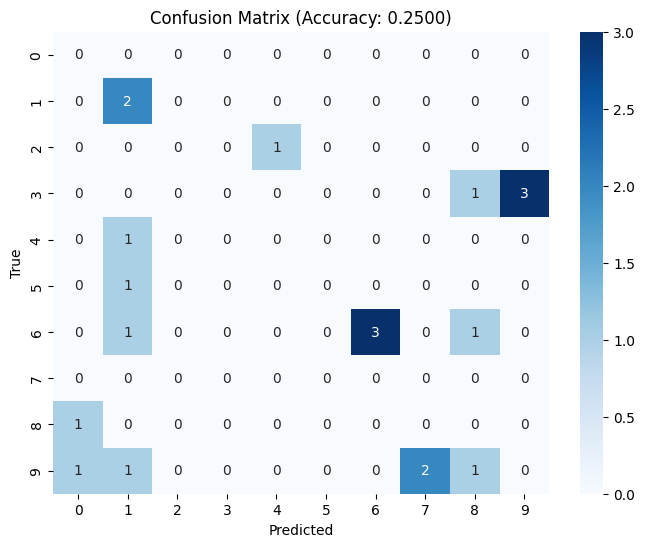


Weight distribution for activation_linear:


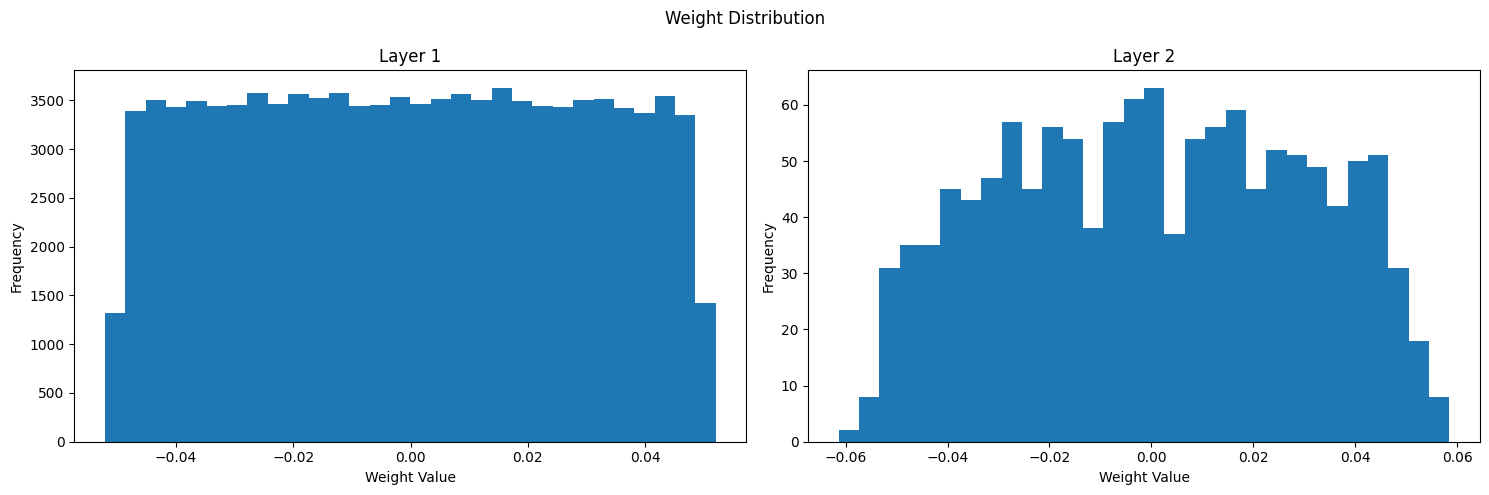


Gradient distribution for activation_linear:


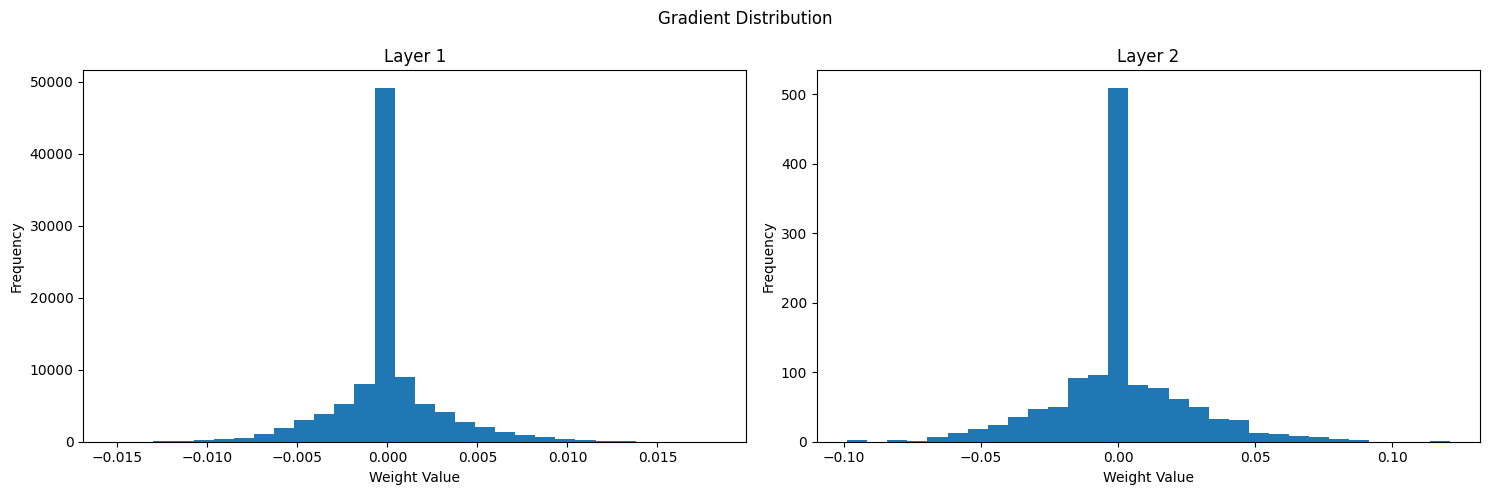


Training model with activation=relu


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.2547 - val_loss: 2.3580


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.2462 - val_loss: 2.3557


...

Epoch 18/20 - loss: 2.1187 - val_loss: 2.3069


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.1112 - val_loss: 2.3035


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.1043 - val_loss: 2.3001

Evaluation for activation_relu:
Test accuracy: 0.3000


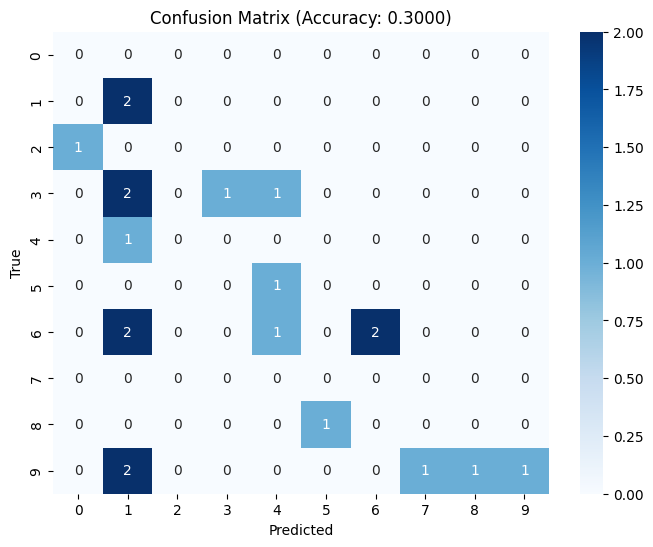


Weight distribution for activation_relu:


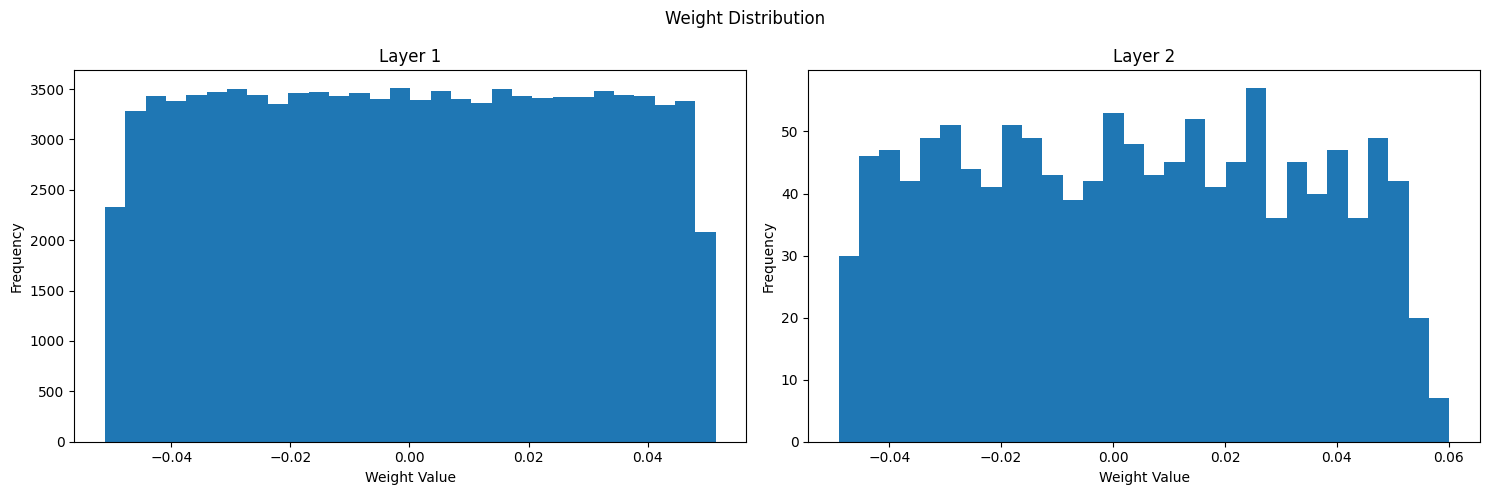


Gradient distribution for activation_relu:


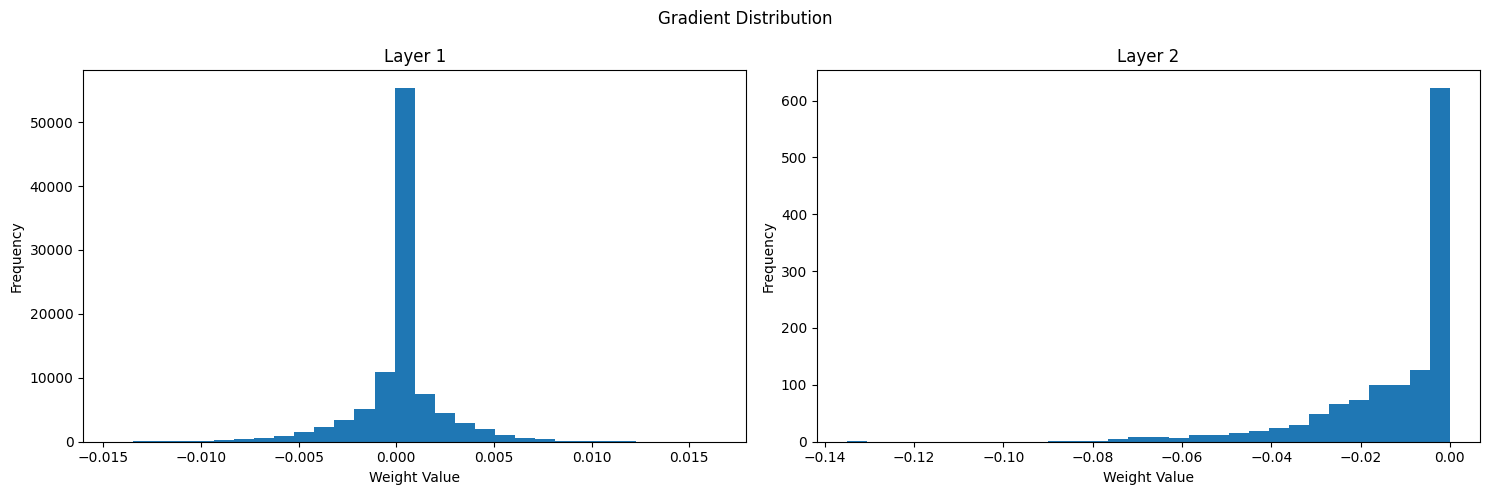


Training model with activation=sigmoid


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3213 - val_loss: 2.2383


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.3174 - val_loss: 2.2447


...

Epoch 18/20 - loss: 2.2358 - val_loss: 2.3337


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.2333 - val_loss: 2.3377


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.2298 - val_loss: 2.3452

Evaluation for activation_sigmoid:
Test accuracy: 0.1000


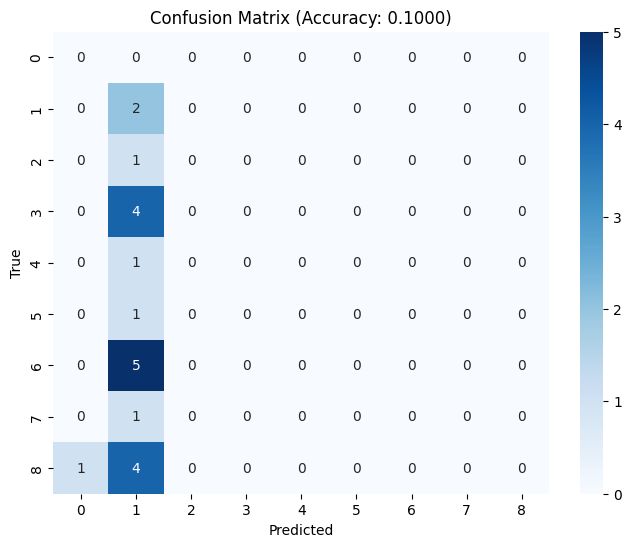


Weight distribution for activation_sigmoid:


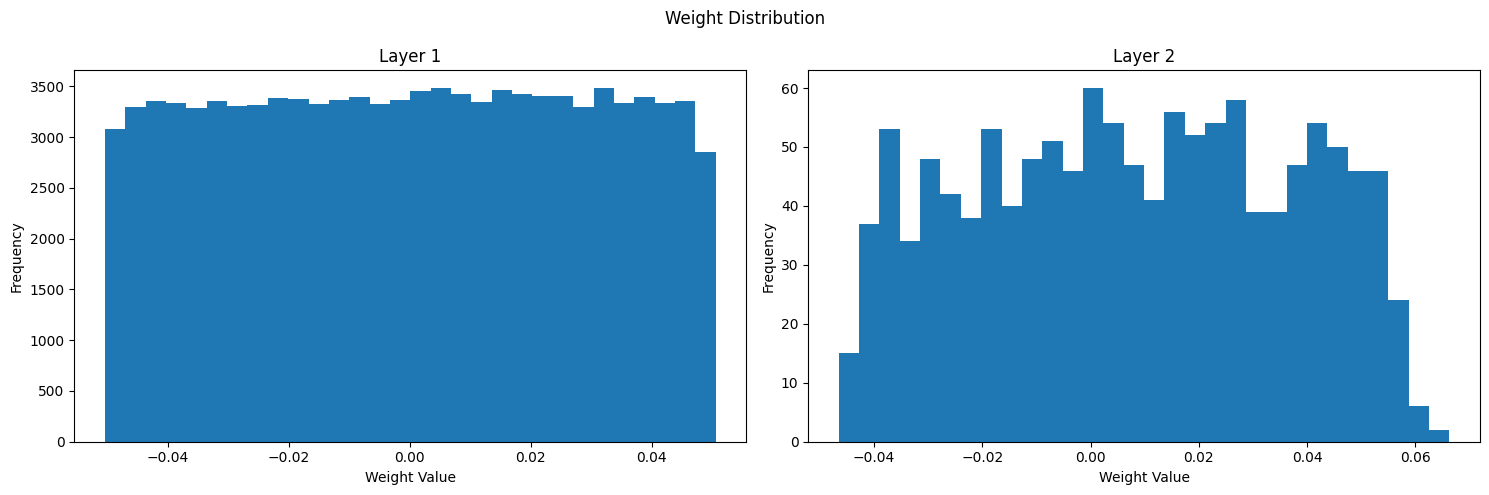


Gradient distribution for activation_sigmoid:


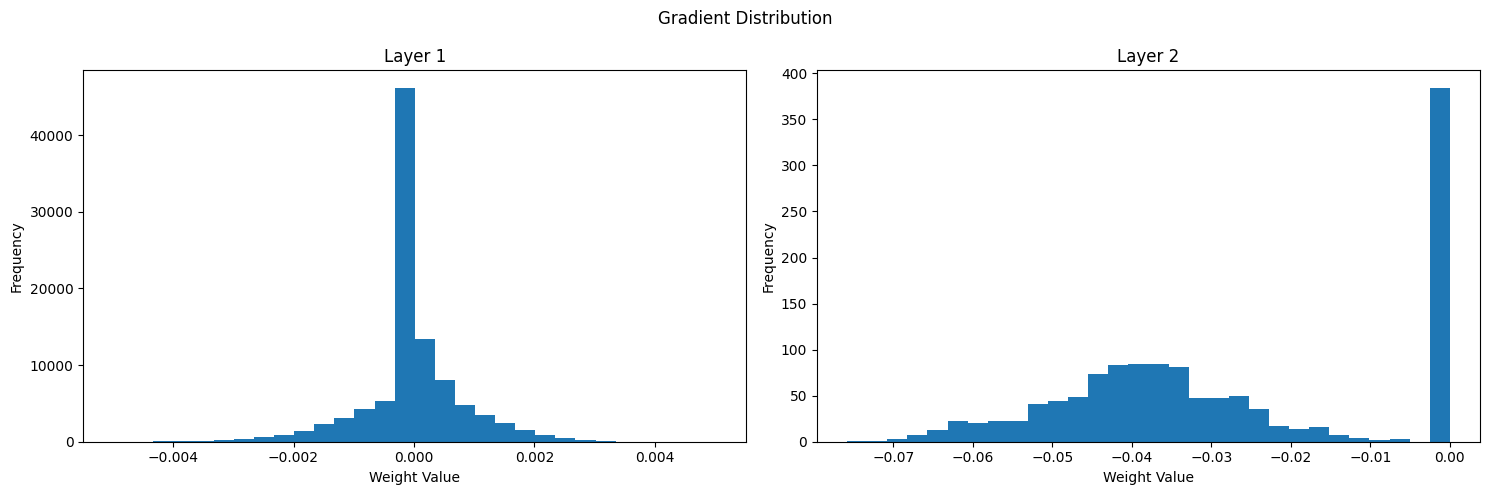


Training model with activation=tanh


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3235 - val_loss: 2.3391


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.3102 - val_loss: 2.3312


...

Epoch 18/20 - loss: 2.0930 - val_loss: 2.2199


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.0814 - val_loss: 2.2147


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.0694 - val_loss: 2.2105

Evaluation for activation_tanh:
Test accuracy: 0.3500


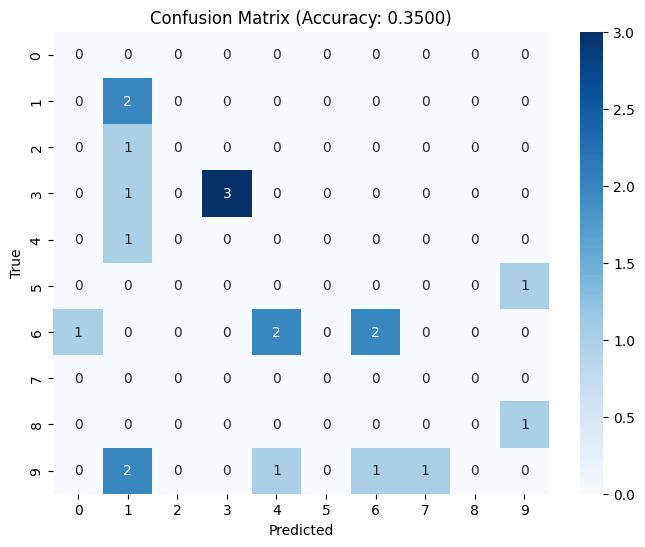


Weight distribution for activation_tanh:


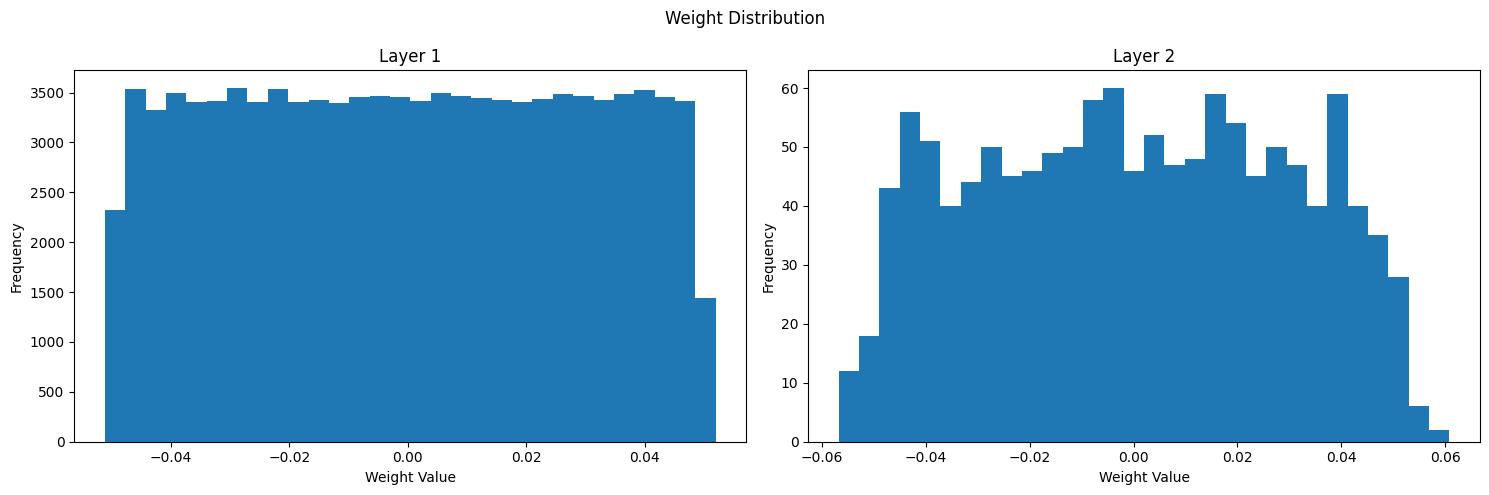


Gradient distribution for activation_tanh:


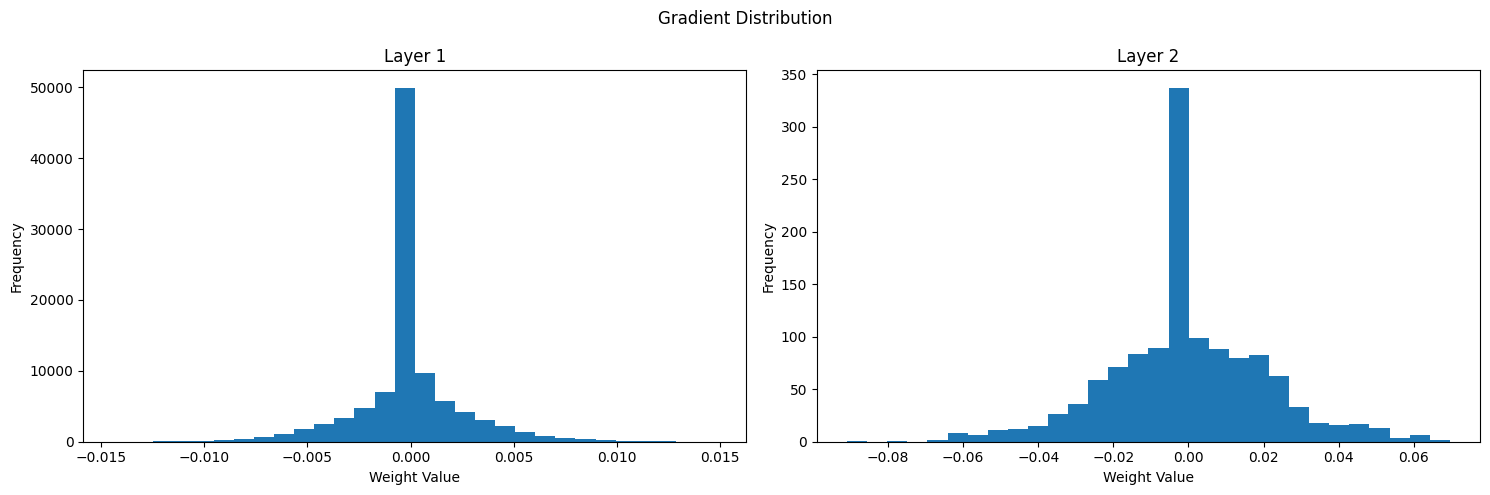

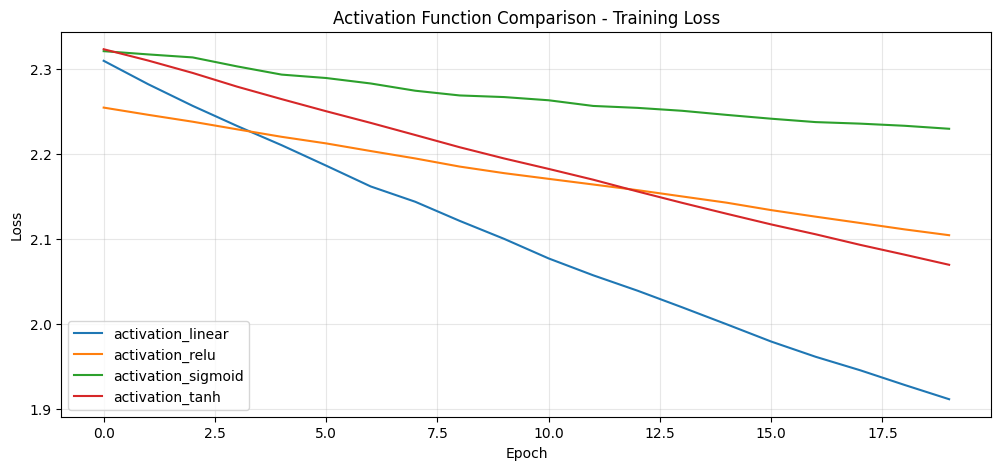

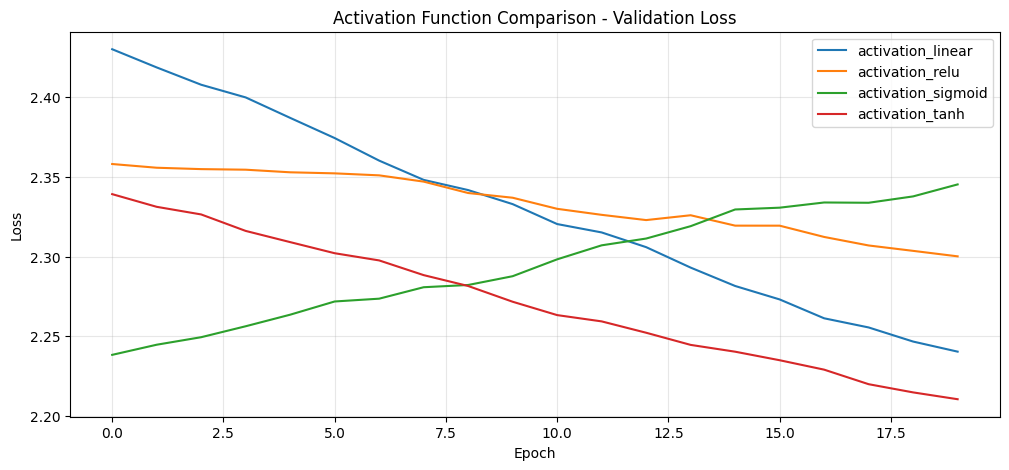

In [ ]:
# activation to test
activation_functions = ['linear', 'relu', 'sigmoid', 'tanh']

fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]

activation_models = {}
activation_histories = {}

print("\n--- Activation Function Experiments ---")
for activation in activation_functions:
    name = f"activation_{activation}"
    
    print(f"\nTraining model with activation={activation}")
    model = FFNN(
        layer_sizes=fixed_layer_sizes,
        activations=[activation, 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='uniform'
    )
    
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        iterator = batch_iterator(X_train, y_train_one_hot, batch_size=batch_size)
        n_batches = int(np.ceil(len(X_train) / batch_size))
        
        for batch_idx, (X_batch, y_batch) in enumerate(tqdm(iterator, total=n_batches, 
                                                        desc=f'Epoch {epoch+1}/{epochs}')):
            # Forward and backward pass
            model.forward(X_batch)
            batch_loss = model.backward(y_batch)
            
            # Update weights
            model.update_weights(learning_rate)
            
            # Accumulate loss
            epoch_loss += batch_loss * len(X_batch) / len(X_train)
        
        history['train_loss'].append(epoch_loss)
        
        val_pred = model.forward(X_test)
        val_loss = model.loss.compute(y_test_one_hot, val_pred)
        history['val_loss'].append(val_loss)
        
        print(f'Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}')
    
    activation_models[name] = model
    activation_histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)

    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    # model.plot_weight()
    if has_nan_weights:
        print("cant plot weight distribution due to nan valuies")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    # model.plot_gradient_distribution()
    if has_nan_gradients:
        print("cant plot weight distribution due to nan valuies")
    else:
        model.plot_gradient_distribution()

plot_comparison(activation_histories, "Activation Function Comparison - Training Loss", "train_loss")
plot_comparison(activation_histories, "Activation Function Comparison - Validation Loss", "val_loss")

## Learning Rate


--- Learning Rate Experiments ---

Training model with learning_rate=0.001


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3097 - val_loss: 2.3142


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.3086 - val_loss: 2.3140


...

Epoch 18/20 - loss: 2.2927 - val_loss: 2.3111


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.2916 - val_loss: 2.3104


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.2906 - val_loss: 2.3102

Evaluation for lr_0.001:
Test accuracy: 0.1000


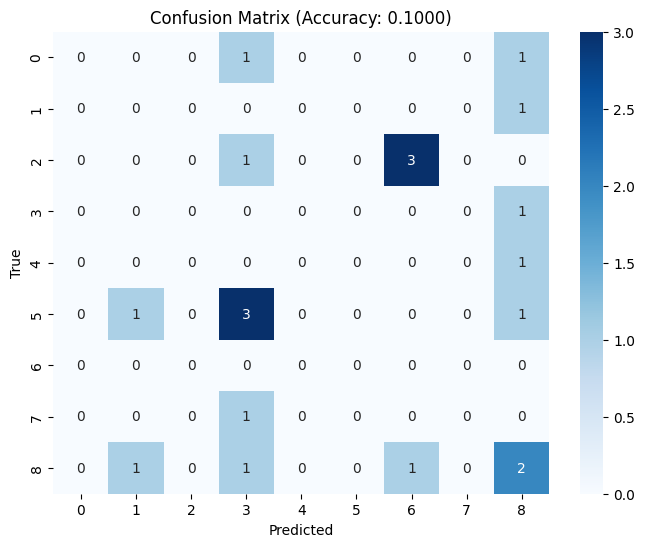


Weight distribution for lr_0.001:


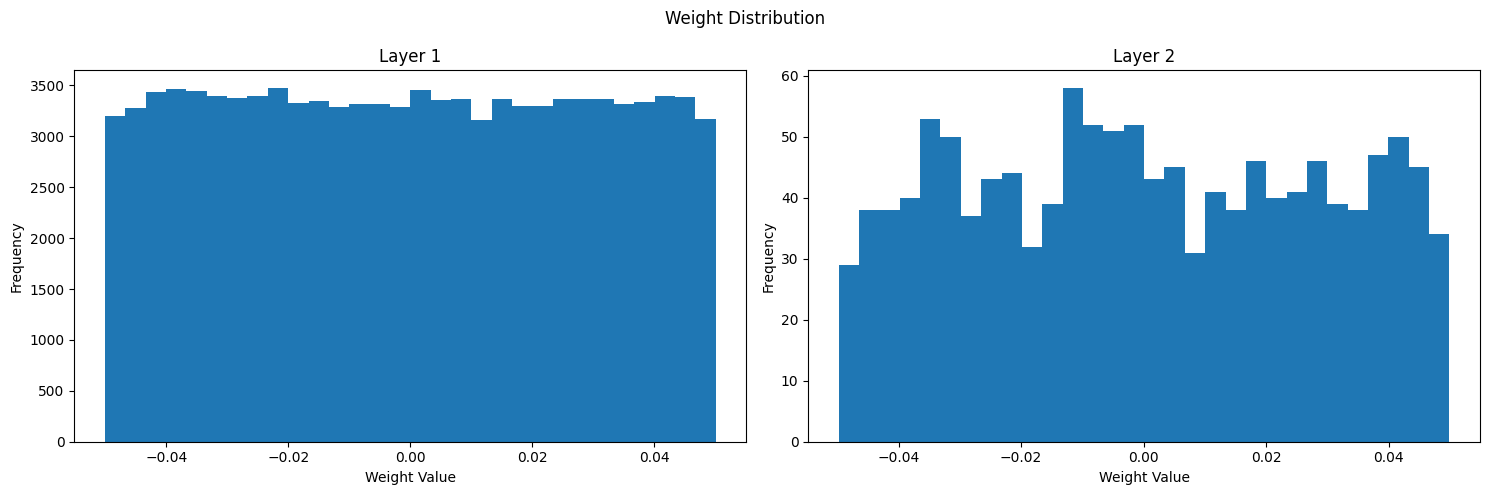


Gradient distribution for lr_0.001:

Training model with learning_rate=0.01


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.2893 - val_loss: 2.3138


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.2793 - val_loss: 2.3138


...

Epoch 18/20 - loss: 2.1348 - val_loss: 2.2693


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.1269 - val_loss: 2.2687


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.1187 - val_loss: 2.2647

Evaluation for lr_0.01:
Test accuracy: 0.2500


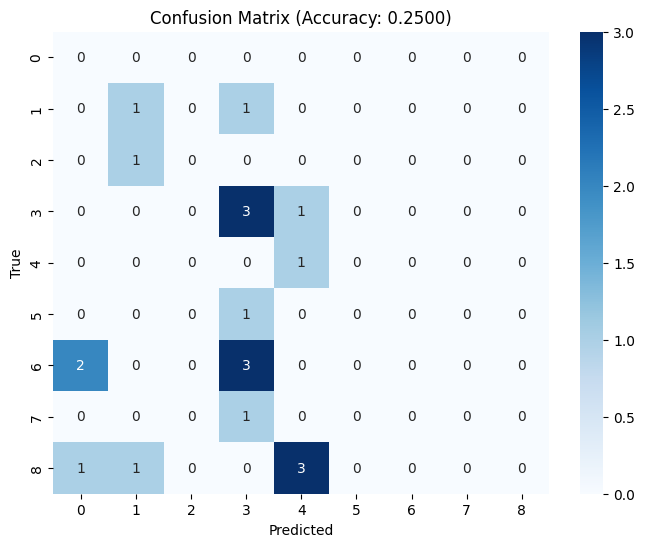


Weight distribution for lr_0.01:


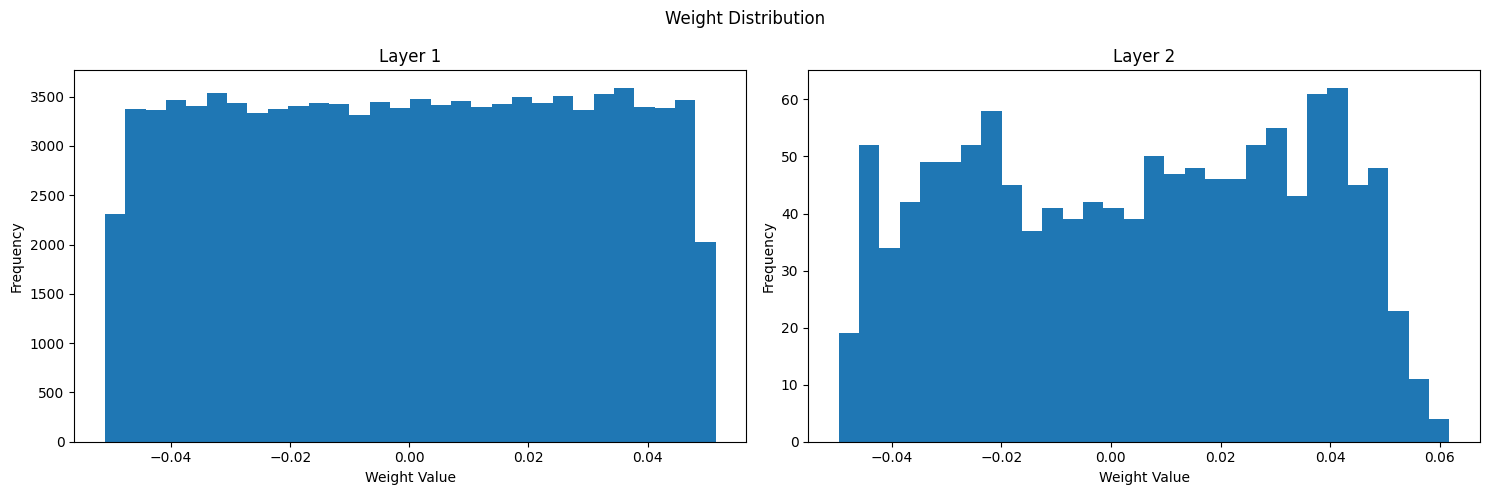


Gradient distribution for lr_0.01:

Training model with learning_rate=0.1


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3273 - val_loss: 2.2542


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.2362 - val_loss: 2.2674


...

Epoch 18/20 - loss: 1.1613 - val_loss: 1.9922


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 1.1168 - val_loss: 1.9802


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 1.0762 - val_loss: 1.9393

Evaluation for lr_0.1:
Test accuracy: 0.3500


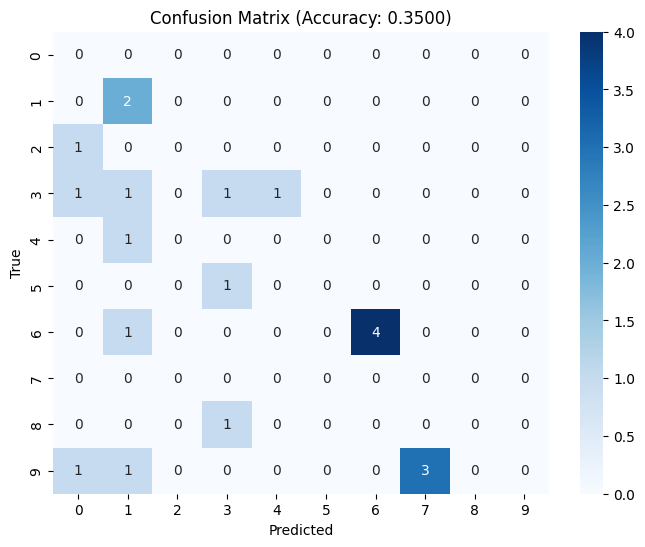


Weight distribution for lr_0.1:


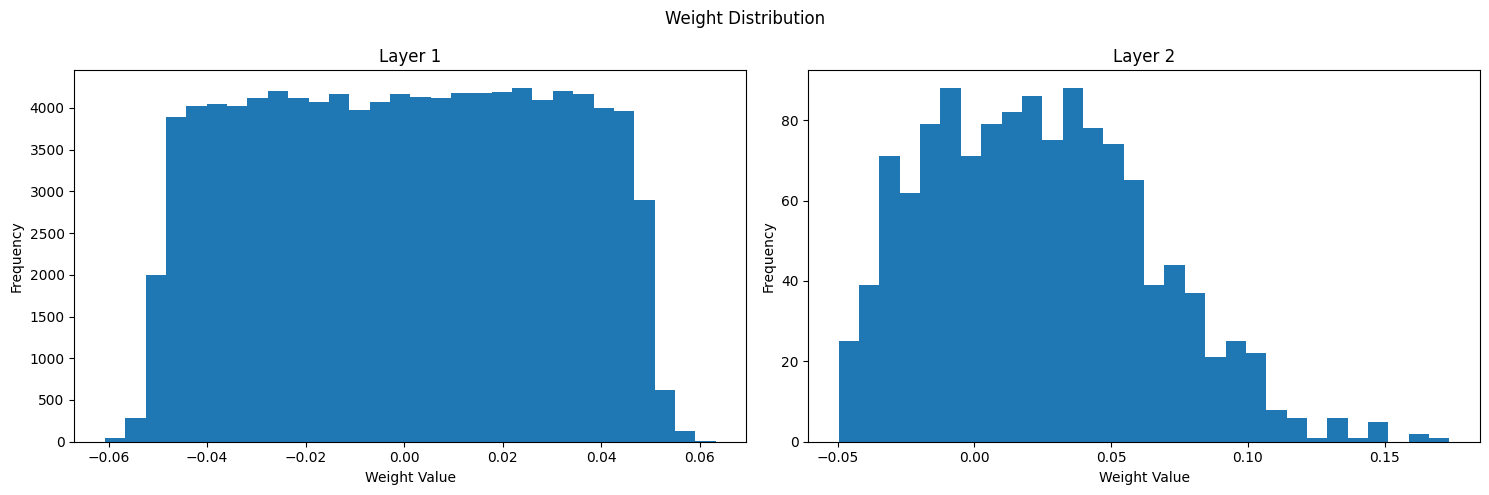


Gradient distribution for lr_0.1:


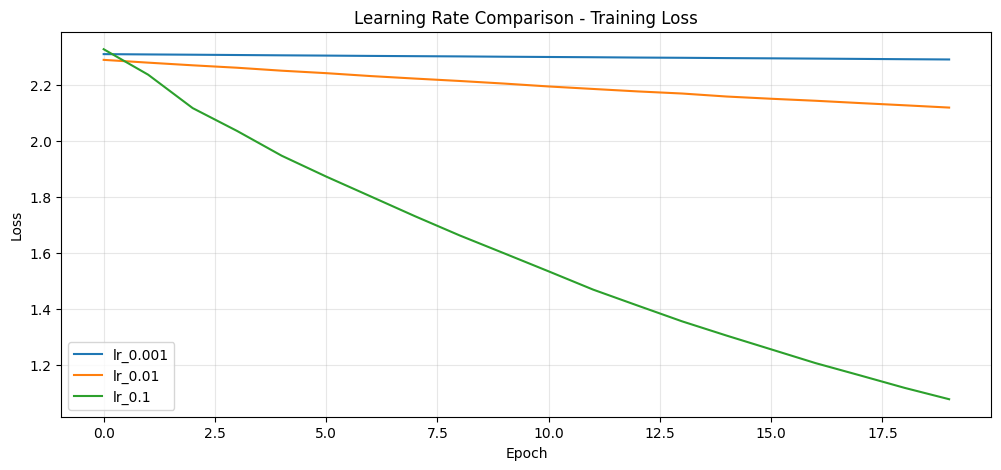

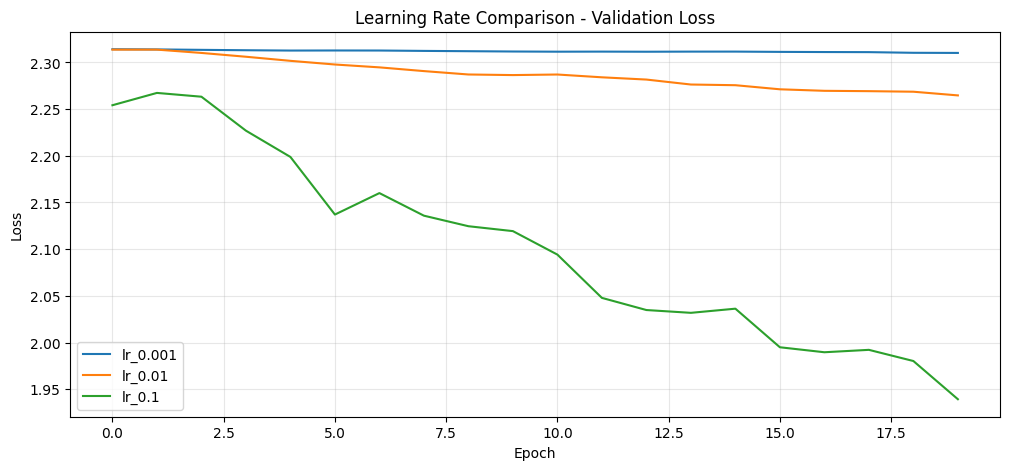

In [ ]:
# Different Learning Rates
learning_rates = [0.001, 0.01, 0.1]

fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]

lr_models = {}
lr_histories = {}

print("\n--- Learning Rate Experiments ---")
for lr in learning_rates:
    name = f"lr_{lr}"
    
    print(f"\nTraining model with learning_rate={lr}")
    model = FFNN(
        layer_sizes=fixed_layer_sizes,
        activations=['relu', 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='uniform'
    )
    
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        iterator = batch_iterator(X_train, y_train_one_hot, batch_size=batch_size)
        n_batches = int(np.ceil(len(X_train) / batch_size))
        
        for batch_idx, (X_batch, y_batch) in enumerate(tqdm(iterator, total=n_batches, 
                                                        desc=f'Epoch {epoch+1}/{epochs}')):
            # Forward and backward pass
            model.forward(X_batch)
            batch_loss = model.backward(y_batch)
            
            # Update weights
            model.update_weights(lr)
            
            # Accumulate loss
            epoch_loss += batch_loss * len(X_batch) / len(X_train)
        
        history['train_loss'].append(epoch_loss)
        
        val_pred = model.forward(X_test)
        val_loss = model.loss.compute(y_test_one_hot, val_pred)
        history['val_loss'].append(val_loss)
        
        print(f'Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}')
    
    lr_models[name] = model
    lr_histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)

    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    # model.plot_weight()
    if has_nan_weights:
        print("cant plot weight distribution. nan values")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    # model.plot_gradient_distribution()
    if has_nan_gradients:
        print("cant plot weight distribution. nan values")
    else:
        model.plot_gradient_distribution()

# Plot training histories
plot_comparison(lr_histories, "Learning Rate Comparison - Training Loss", "train_loss")
plot_comparison(lr_histories, "Learning Rate Comparison - Validation Loss", "val_loss")

## Weight Initialization


--- Weight Initialization Experiments ---

Training model with initializer=zero


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3026 - val_loss: 2.3026


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.3025 - val_loss: 2.3025


...

Epoch 18/20 - loss: 2.3011 - val_loss: 2.3035


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.3008 - val_loss: 2.3038


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.3007 - val_loss: 2.3038

Evaluation for init_zero:
Test accuracy: 0.1000


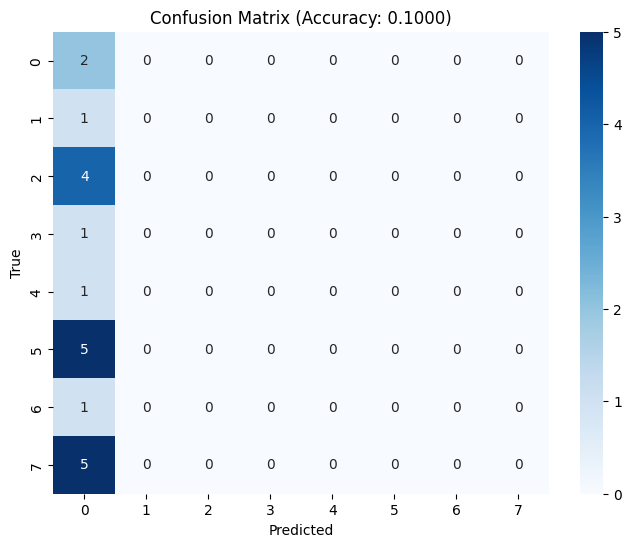


Weight distribution for init_zero:


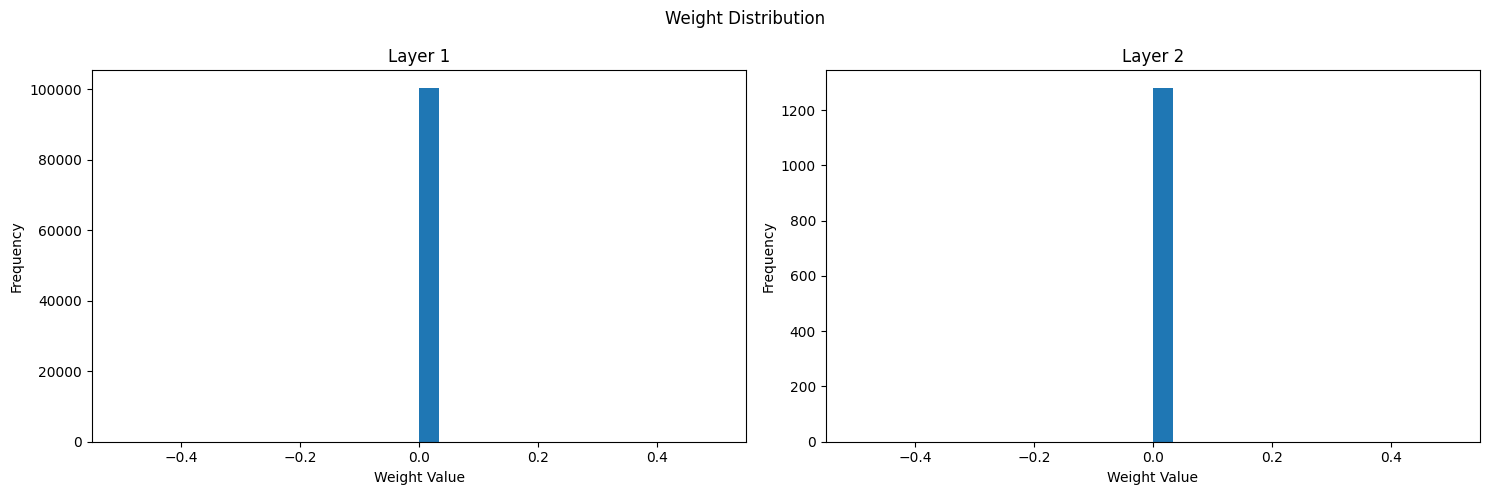


Gradient distribution for init_zero:


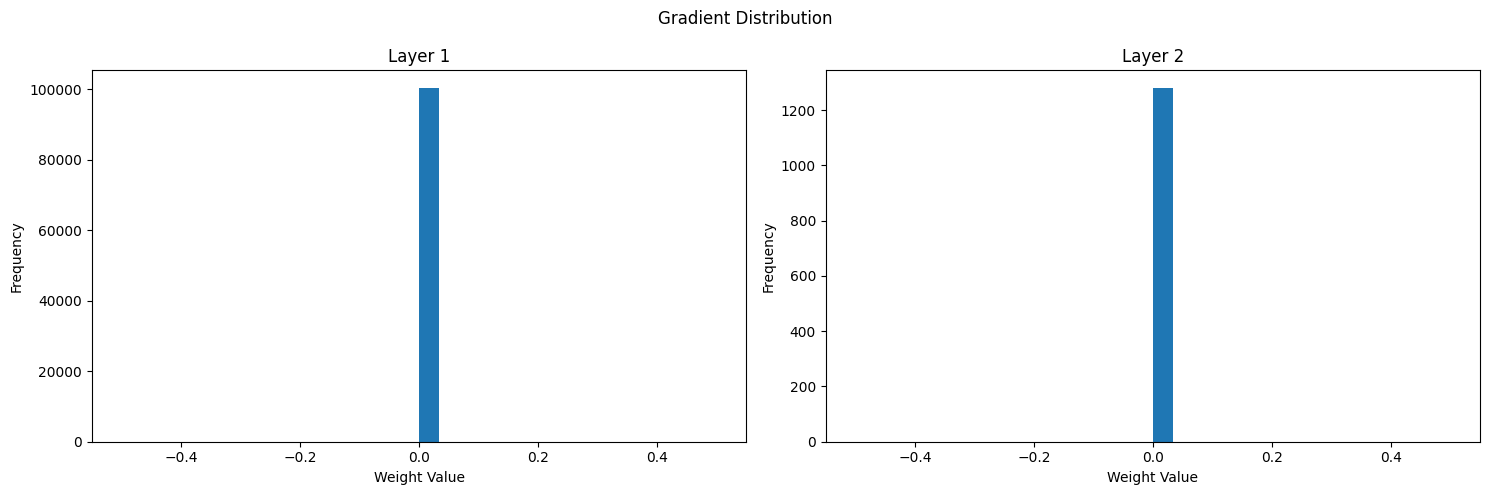


Training model with initializer=uniform


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.2902 - val_loss: 2.3410


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.2812 - val_loss: 2.3418


...

Epoch 18/20 - loss: 2.1541 - val_loss: 2.3077


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.1459 - val_loss: 2.3053


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.1397 - val_loss: 2.3042

Evaluation for init_uniform:
Test accuracy: 0.2000


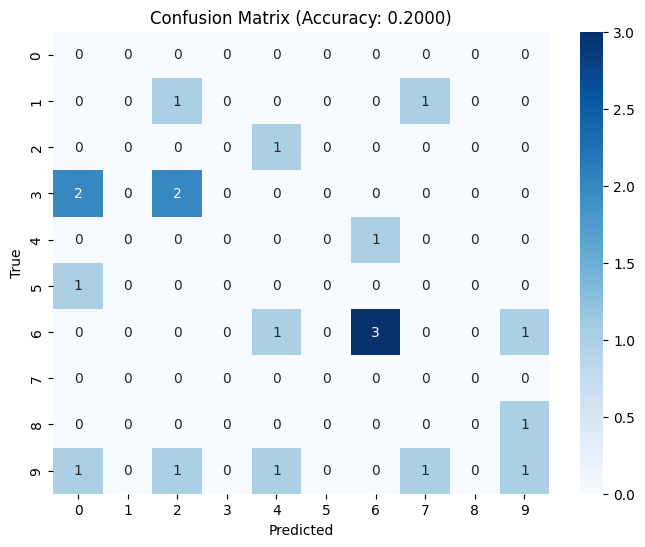


Weight distribution for init_uniform:


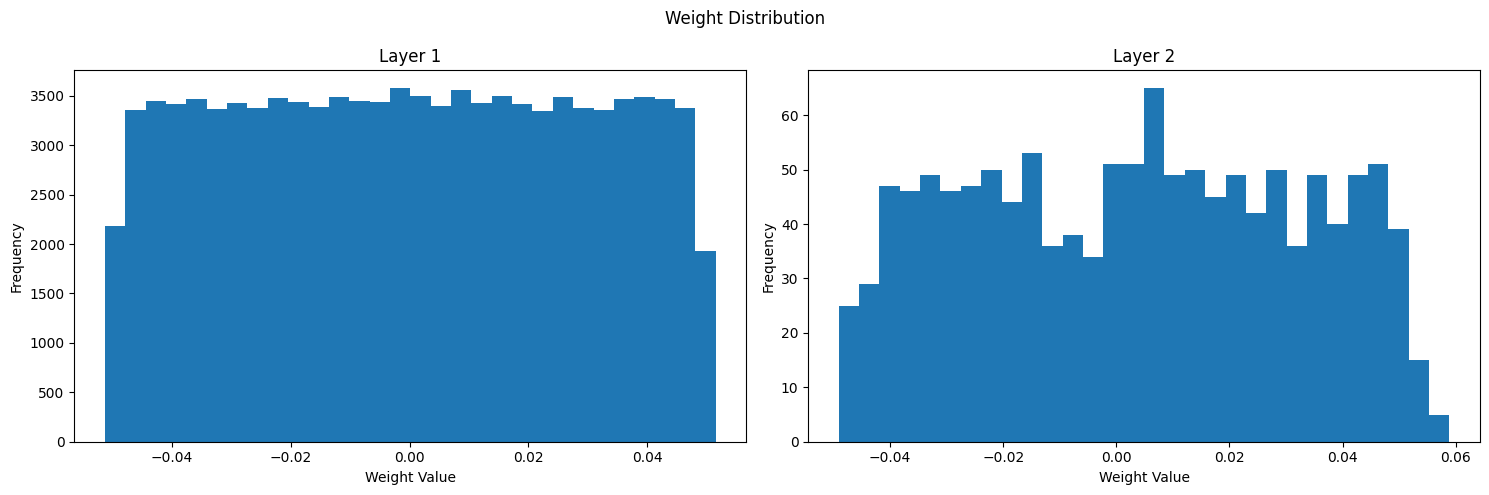


Gradient distribution for init_uniform:


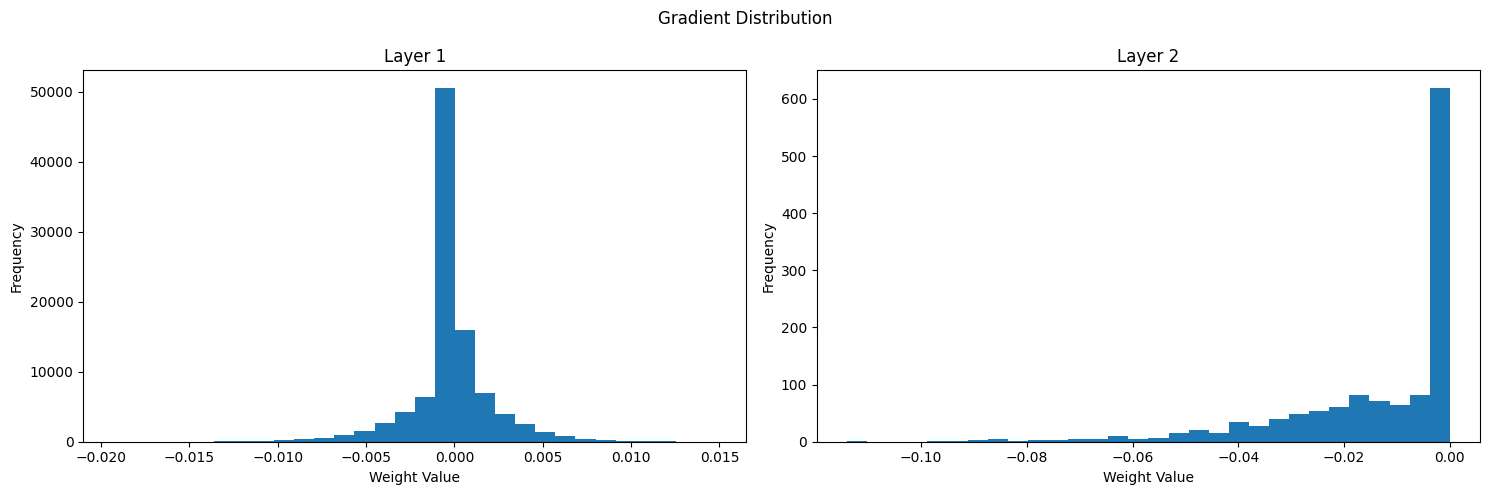


Training model with initializer=normal


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3344 - val_loss: 2.4781


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.3010 - val_loss: 2.4518


...

Epoch 18/20 - loss: 1.9278 - val_loss: 2.3852


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 1.9115 - val_loss: 2.3805


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 1.8938 - val_loss: 2.3776

Evaluation for init_normal:
Test accuracy: 0.2000


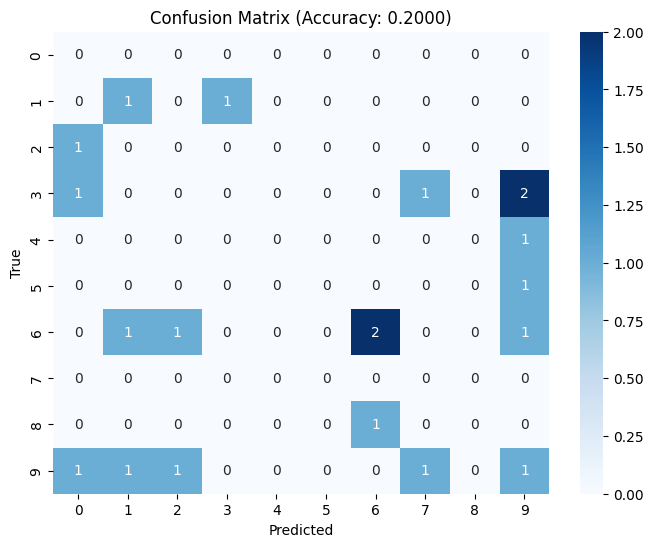


Weight distribution for init_normal:


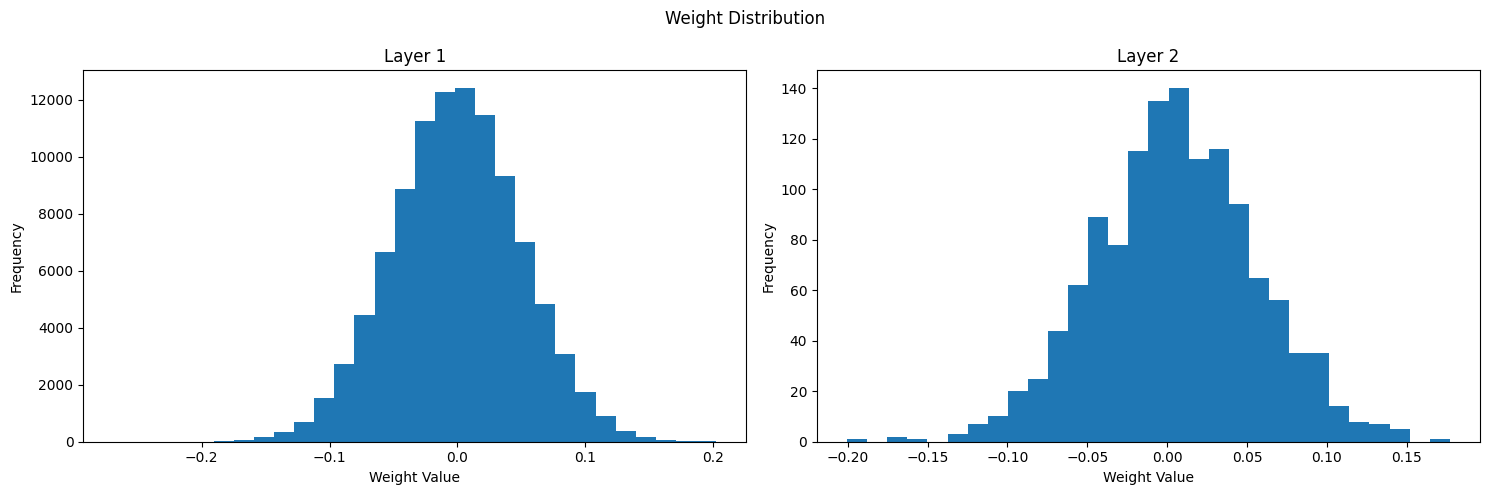


Gradient distribution for init_normal:


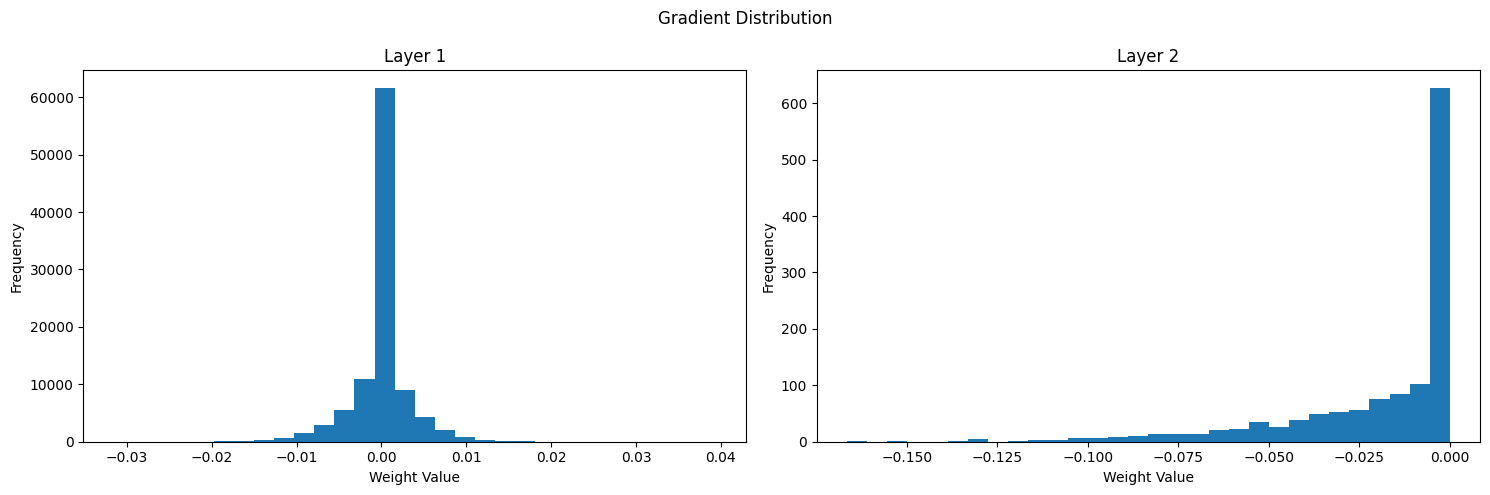


Training model with initializer=xavier


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.7447 - val_loss: 2.4470


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.4160 - val_loss: 2.3495


...

Epoch 18/20 - loss: 1.4696 - val_loss: 1.9364


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 1.4410 - val_loss: 1.9154


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 1.4130 - val_loss: 1.9029

Evaluation for init_xavier:
Test accuracy: 0.3500


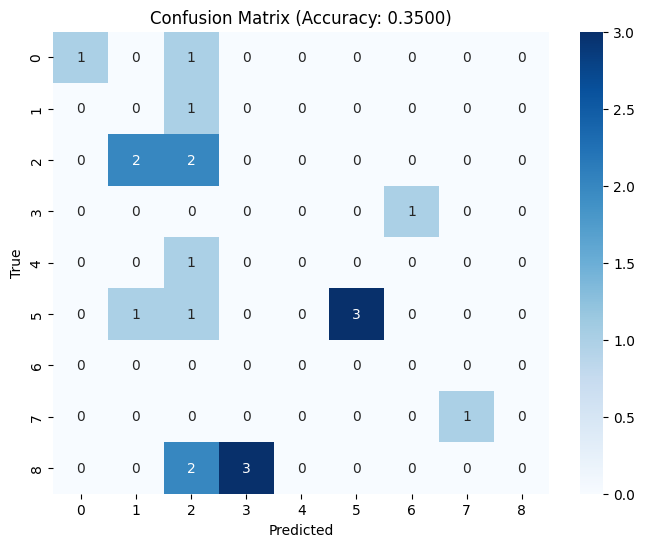


Weight distribution for init_xavier:


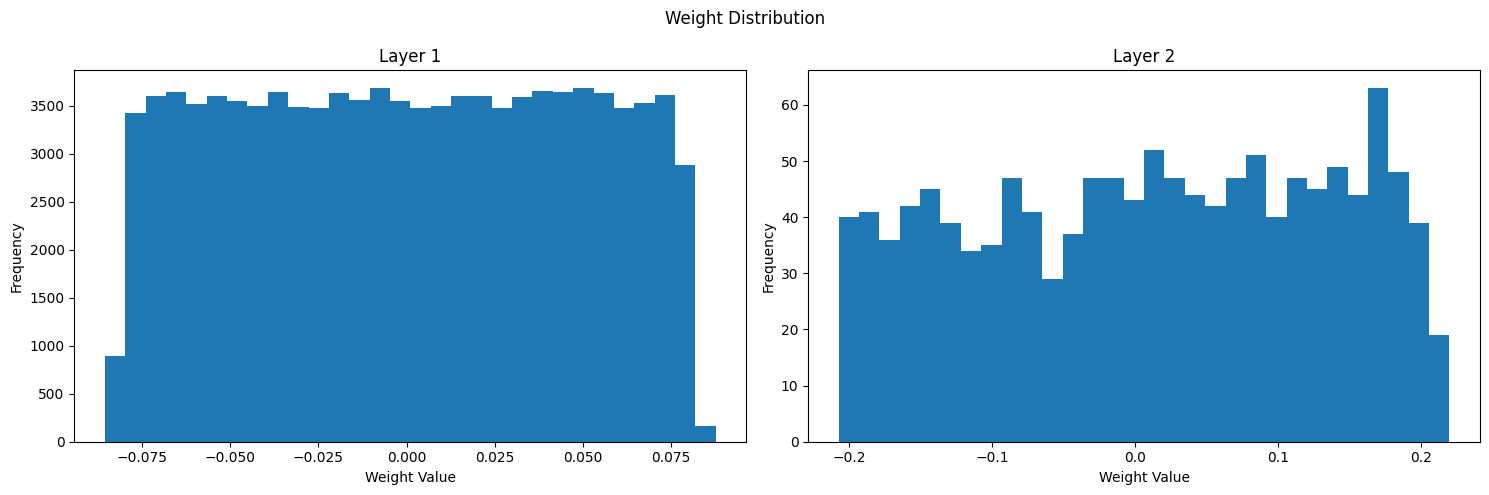


Gradient distribution for init_xavier:


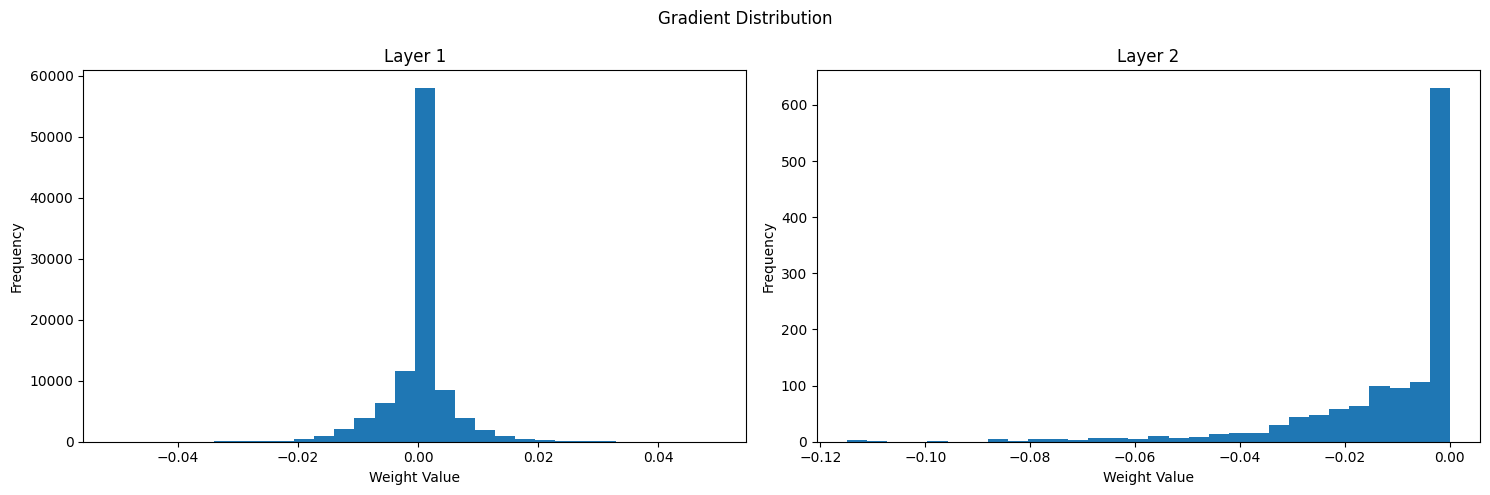


Training model with initializer=he


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 3.0546 - val_loss: 3.6396


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.8401 - val_loss: 31.2709


...

Epoch 18/20 - loss: nan - val_loss: nan


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: nan - val_loss: nan


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: nan - val_loss: nan

Evaluation for init_he:
Test accuracy: 0.0000


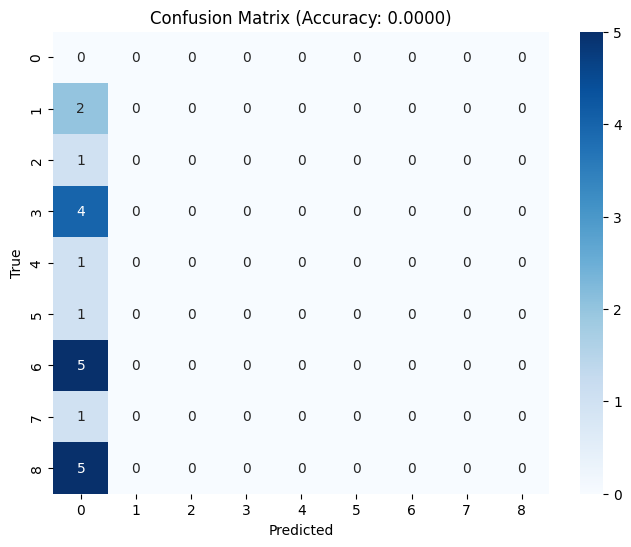


Weight distribution for init_he:
Error with initializer he: autodetected range of [nan, nan] is not finite


c:\Python311\Lib\site-packages\matplotlib\axes\_axes.py:6826: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
c:\Python311\Lib\site-packages\matplotlib\axes\_axes.py:6827: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


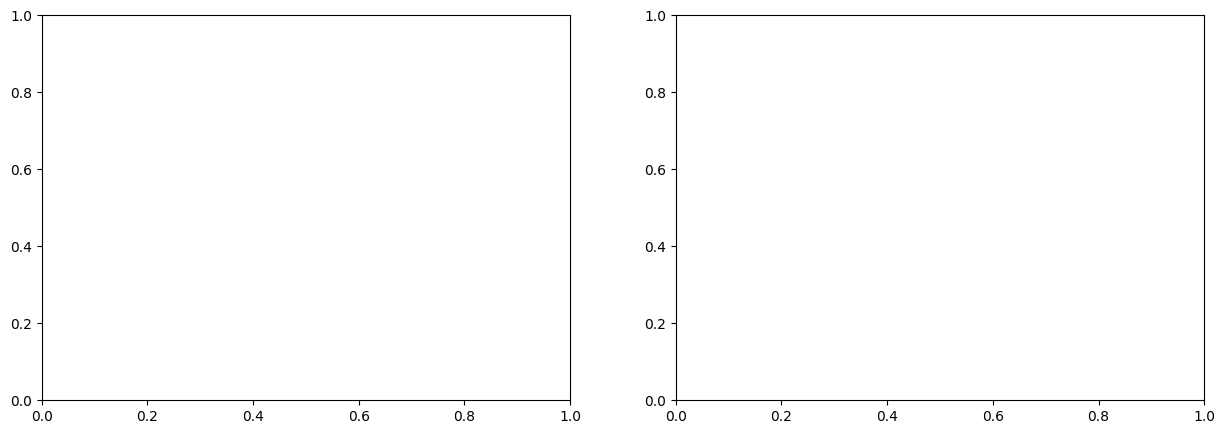

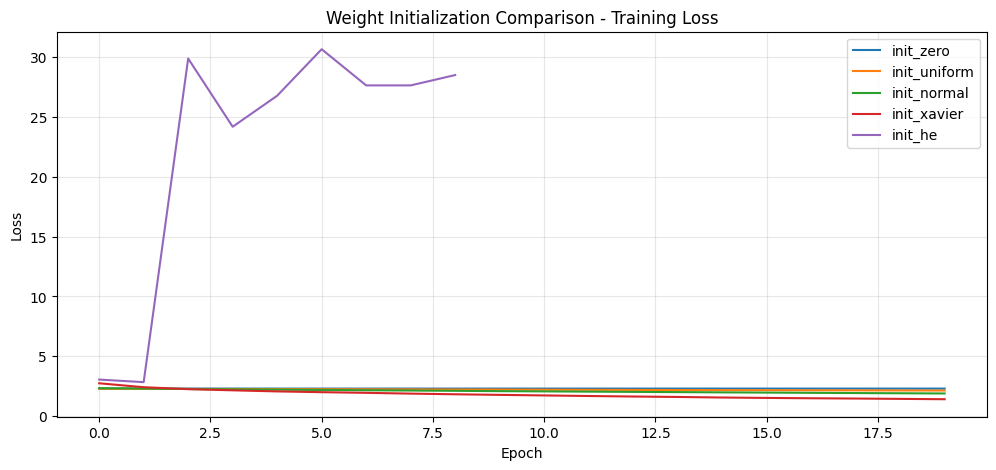

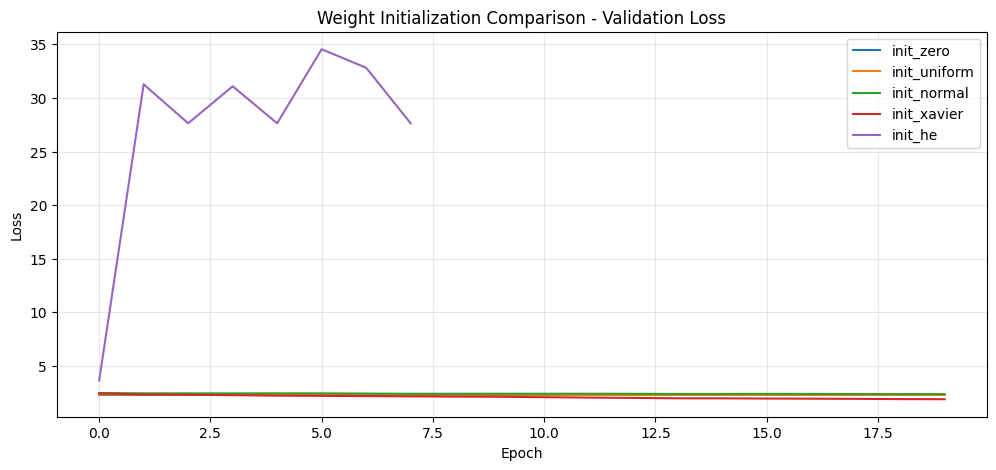

In [ ]:
initializers = [
    {'name': 'zero', 'params': {}},
    {'name': 'uniform', 'params': {'low': -0.05, 'high': 0.05}},
    {'name': 'normal', 'params': {'mean': 0, 'std': 0.05}},
    # Bonus initializers (masih tes tes)
    {'name': 'xavier', 'params': {}},
    {'name': 'he', 'params': {}}
]

fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]
fixed_lr = 0.01

init_models = {}
init_histories = {}

print("\n--- Weight Initialization Experiments ---")
for init in initializers:
    name = f"init_{init['name']}"
    
    try:
        print(f"\nTraining model with initializer={init['name']}")
        model = FFNN(
            layer_sizes=fixed_layer_sizes,
            activations=['relu', 'softmax'],
            loss='categorical_cross_entropy',
            weight_initializer=init['name'],
            weight_init_params=init['params']
        )
        
        history = {'train_loss': [], 'val_loss': []}
        
        for epoch in range(epochs):
            epoch_loss = 0.0
            
            iterator = batch_iterator(X_train, y_train_one_hot, batch_size=batch_size)
            n_batches = int(np.ceil(len(X_train) / batch_size))
            
            for batch_idx, (X_batch, y_batch) in enumerate(tqdm(iterator, total=n_batches, 
                                                            desc=f'Epoch {epoch+1}/{epochs}')):
                # Forward and backward pass
                model.forward(X_batch)
                batch_loss = model.backward(y_batch)
                
                # Update weights
                model.update_weights(fixed_lr)
                
                # Accumulate loss
                epoch_loss += batch_loss * len(X_batch) / len(X_train)
            
            history['train_loss'].append(epoch_loss)
            
            val_pred = model.forward(X_test)
            val_loss = model.loss.compute(y_test_one_hot, val_pred)
            history['val_loss'].append(val_loss)
            
            print(f'Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}')
        
        init_models[name] = model
        init_histories[name] = history
        
        # Evaluate model
        print(f"\nEvaluation for {name}:")
        evaluate_model(model, X_test, y_test, y_test_one_hot)
    
        has_nan_weights = any(np.isnan(w).any() for w in model.weights)
        has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
        
        # Plot weight distribution
        print(f"\nWeight distribution for {name}:")
        # model.plot_weight()
        if has_nan_weights:
            print("cant plot weight distribution. nan values")
        else:
            model.plot_weight()
        
        # Plot gradient distribution
        print(f"\nGradient distribution for {name}:")
        # model.plot_gradient_distribution()
        if has_nan_gradients:
            print("cant plot weight distribution. nan values")
        else:
            model.plot_gradient_distribution()
    
    except Exception as e:
        print(f"Error with initializer {init['name']}: {e}")

# Plot training histories for successful initializers
valid_initializers = init_histories.keys()
if valid_initializers:
    plot_comparison(init_histories, "Weight Initialization Comparison - Training Loss", "train_loss")
    plot_comparison(init_histories, "Weight Initialization Comparison - Validation Loss", "val_loss")

## Comparison


--- Sklearn Comparison ---

Training custom FFNN model


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.2956 - val_loss: 2.3770


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.2843 - val_loss: 2.3699


...

Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.1409 - val_loss: 2.3288


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.1327 - val_loss: 2.3269

Evaluation for custom FFNN model:
Custom FFNN test accuracy: 0.1500

Training sklearn MLPClassifier
Iteration 1, loss = 2.99966944
Iteration 2, loss = 2.25841954
Iteration 3, loss = 1.46497365
Iteration 4, loss = 0.88837742
Iteration 5, loss = 0.54943480
Iteration 6, loss = 0.34957474
Iteration 7, loss = 0.23675421
Iteration 8, loss = 0.16539614
Iteration 9, loss = 0.12185042
Iteration 10, loss = 0.09099457
Iteration 11, loss = 0.07075758
Iteration 12, loss = 0.05558416
Iteration 13, loss = 0.04502264
Iteration 14, loss = 0.03593587
Iteration 15, loss = 0.02995751
Iteration 16, loss = 0.02491766
Iteration 17, loss = 0.02094526
Iteration 18, loss = 0.01832783
Iteration 19, loss = 0.01601693
Iteration 20, loss = 0.01461195
Sklearn MLPClassifier test accuracy: 0.6000

Accuracy comparison:
Custom FFNN: 0.1500
Sklearn MLP: 0.6000
Agreement between models: 0.3500


c:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


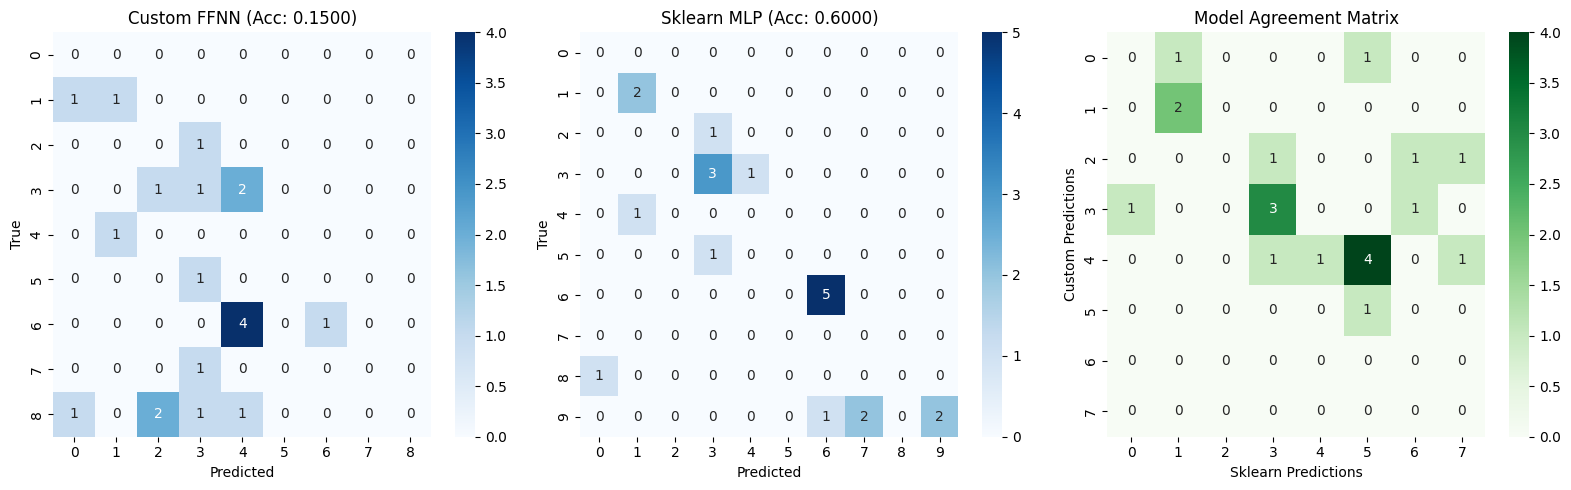

In [ ]:
fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]
fixed_lr = 0.01
fixed_activation = 'relu'

# custom FFNN model
print("\n--- Sklearn Comparison ---")
print("\nTraining custom FFNN model")
custom_model = FFNN(
    layer_sizes=fixed_layer_sizes,
    activations=[fixed_activation, 'softmax'],
    loss='categorical_cross_entropy',
    weight_initializer='uniform'
)

custom_history = {'train_loss': [], 'val_loss': []}

for epoch in range(epochs):
    epoch_loss = 0.0
    
    iterator = batch_iterator(X_train, y_train_one_hot, batch_size=batch_size)
    n_batches = int(np.ceil(len(X_train) / batch_size))
    
    for batch_idx, (X_batch, y_batch) in enumerate(tqdm(iterator, total=n_batches, 
                                                    desc=f'Epoch {epoch+1}/{epochs}')):
        # Forward and backward pass
        custom_model.forward(X_batch)
        batch_loss = custom_model.backward(y_batch)
        
        # Update weights
        custom_model.update_weights(fixed_lr)
        
        # Accumulate loss
        epoch_loss += batch_loss * len(X_batch) / len(X_train)
    
    custom_history['train_loss'].append(epoch_loss)
    
    val_pred = custom_model.forward(X_test)
    val_loss = custom_model.loss.compute(y_test_one_hot, val_pred)
    custom_history['val_loss'].append(val_loss)
    
    print(f'Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}')

# Evaluate custom model
print("\nEvaluation for custom FFNN model:")
custom_pred = custom_model.predict(X_test)
custom_pred_class = np.argmax(custom_pred, axis=1)
custom_acc = accuracy_score(y_test, custom_pred_class)
print(f"Custom FFNN test accuracy: {custom_acc:.4f}")

# sklearn model
print("\nTraining sklearn MLPClassifier")
sklearn_model = MLPClassifier(
    hidden_layer_sizes=(fixed_width,),
    activation=fixed_activation,
    solver='sgd',
    alpha=0.0001,  # L2
    batch_size=batch_size,
    learning_rate_init=fixed_lr,
    max_iter=epochs,
    shuffle=True,
    random_state=42,
    verbose=True
)

sklearn_model.fit(X_train, y_train)

# Evaluate sklearn model
sklearn_pred = sklearn_model.predict(X_test)
sklearn_acc = accuracy_score(y_test, sklearn_pred)
print(f"Sklearn MLPClassifier test accuracy: {sklearn_acc:.4f}")

# Compare models
print(f"\nAccuracy comparison:")
print(f"Custom FFNN: {custom_acc:.4f}")
print(f"Sklearn MLP: {sklearn_acc:.4f}")

# Compare predictions
agreement = np.mean(custom_pred_class == sklearn_pred)
print(f"Agreement between models: {agreement:.4f}")

plt.figure(figsize=(16, 5))

# Custom FFNN confusion matrix
plt.subplot(1, 3, 1)
custom_cm = confusion_matrix(y_test, custom_pred_class)
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Custom FFNN (Acc: {custom_acc:.4f})')
plt.xlabel('Predicted')
plt.ylabel('True')

# Sklearn model confusion matrix
plt.subplot(1, 3, 2)
sklearn_cm = confusion_matrix(y_test, sklearn_pred)
sns.heatmap(sklearn_cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Sklearn MLP (Acc: {sklearn_acc:.4f})')
plt.xlabel('Predicted')
plt.ylabel('True')

# Plot agreement
plt.subplot(1, 3, 3)
agreement_cm = confusion_matrix(custom_pred_class, sklearn_pred)
sns.heatmap(agreement_cm, annot=True, fmt='d', cmap='Greens')
plt.title('Model Agreement Matrix')
plt.xlabel('Sklearn Predictions')
plt.ylabel('Custom Predictions')

plt.tight_layout()
plt.show()

## Regularizers


--- Regularization Experiments ---

Training model with regularizer=None


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3053 - val_loss: 2.3568


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.2948 - val_loss: 2.3543


...

Epoch 18/20 - loss: 2.1510 - val_loss: 2.3145


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.1433 - val_loss: 2.3135


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.1350 - val_loss: 2.3140

Evaluation for reg_None:
Test accuracy: 0.1500


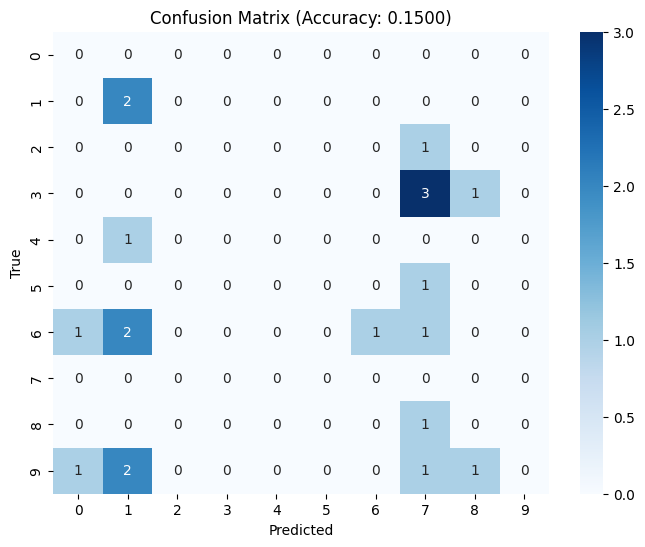


Weight distribution for reg_None:


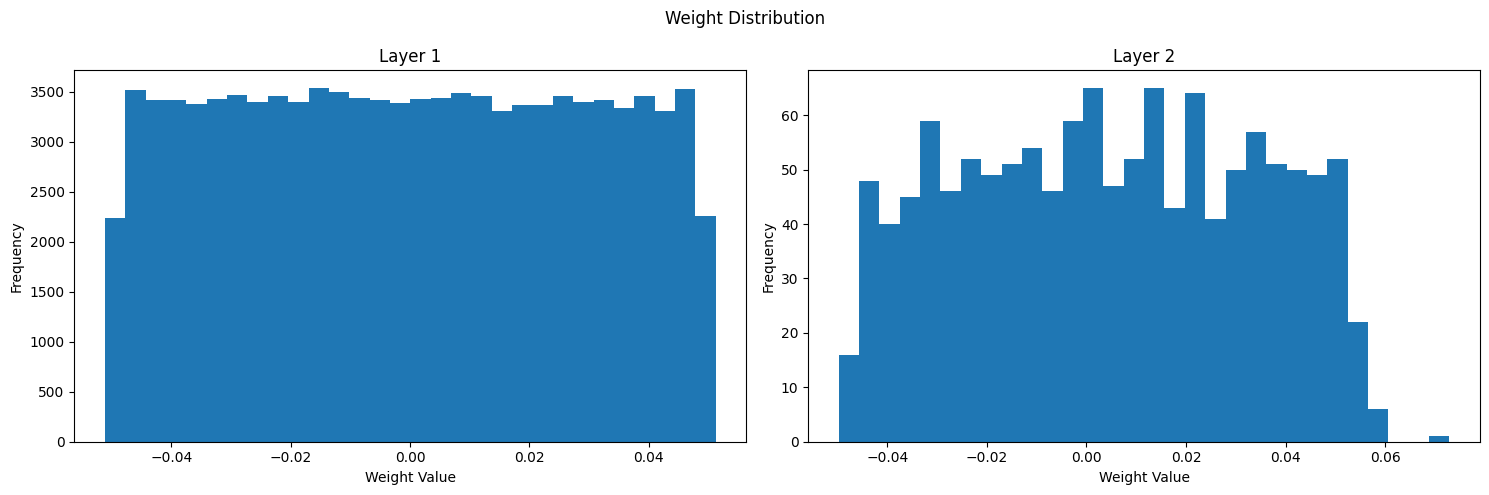


Gradient distribution for reg_None:


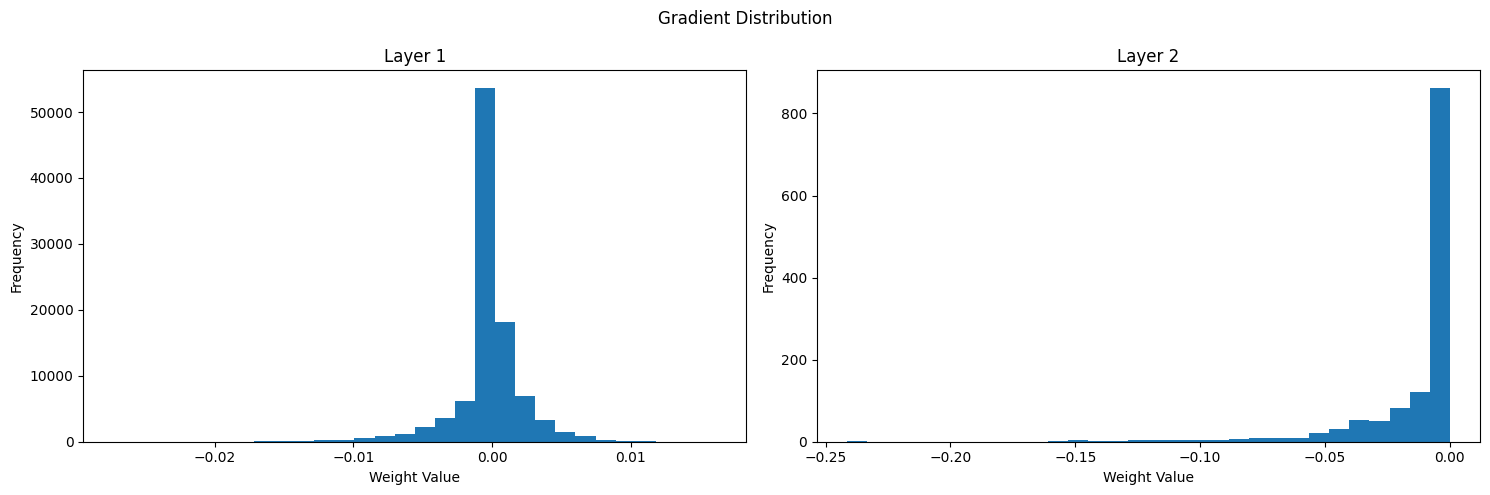


Training model with regularizer=L1


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 27.7387 - val_loss: 2.3680


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 27.5262 - val_loss: 2.3601


...

Epoch 18/20 - loss: 24.2832 - val_loss: 2.3304


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 24.0909 - val_loss: 2.3283


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 23.8980 - val_loss: 2.3287

Evaluation for reg_L1:
Test accuracy: 0.0500


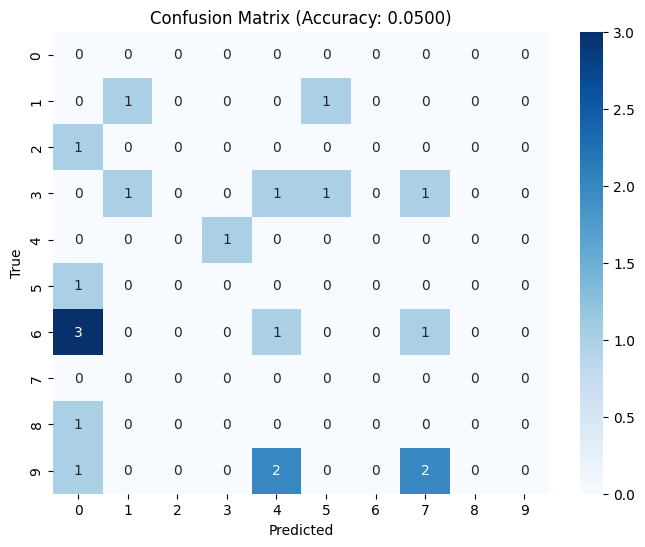


Weight distribution for reg_L1:


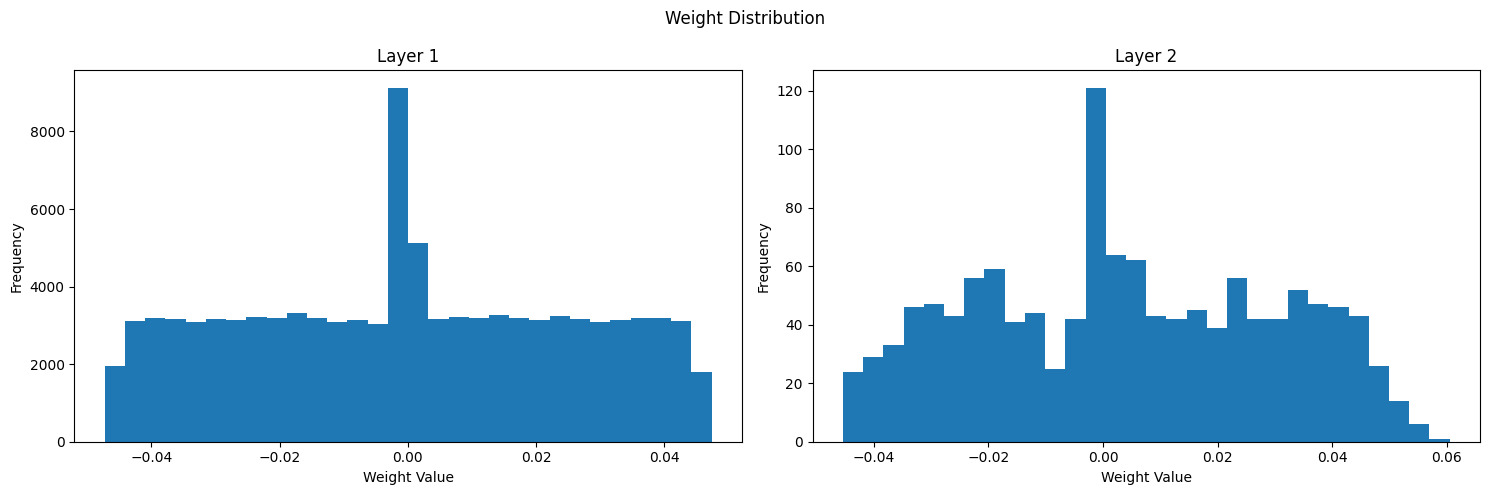


Gradient distribution for reg_L1:


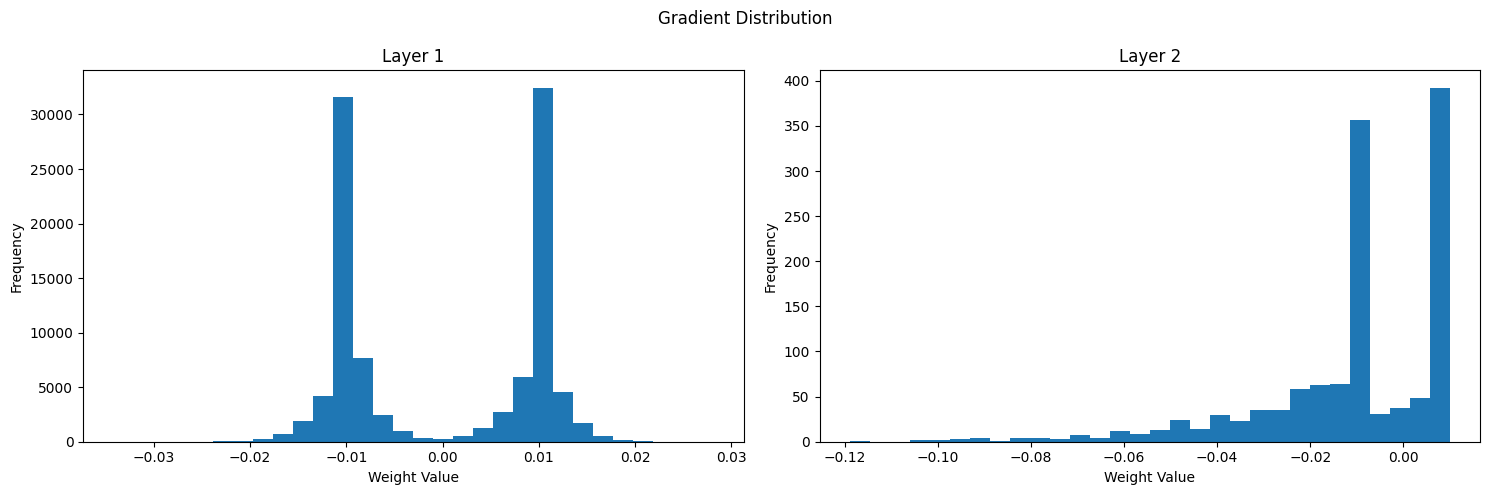


Training model with regularizer=L2


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.7210 - val_loss: 2.3954


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.7105 - val_loss: 2.3960


...

Epoch 18/20 - loss: 2.5707 - val_loss: 2.3466


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.5634 - val_loss: 2.3424


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.5550 - val_loss: 2.3385

Evaluation for reg_L2:
Test accuracy: 0.2000


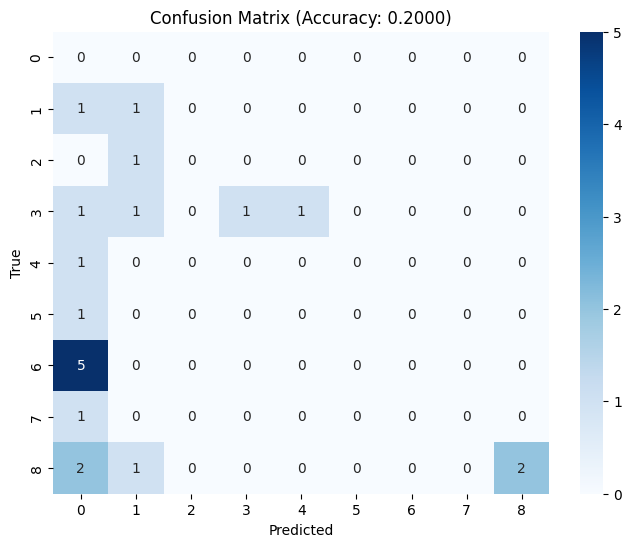


Weight distribution for reg_L2:


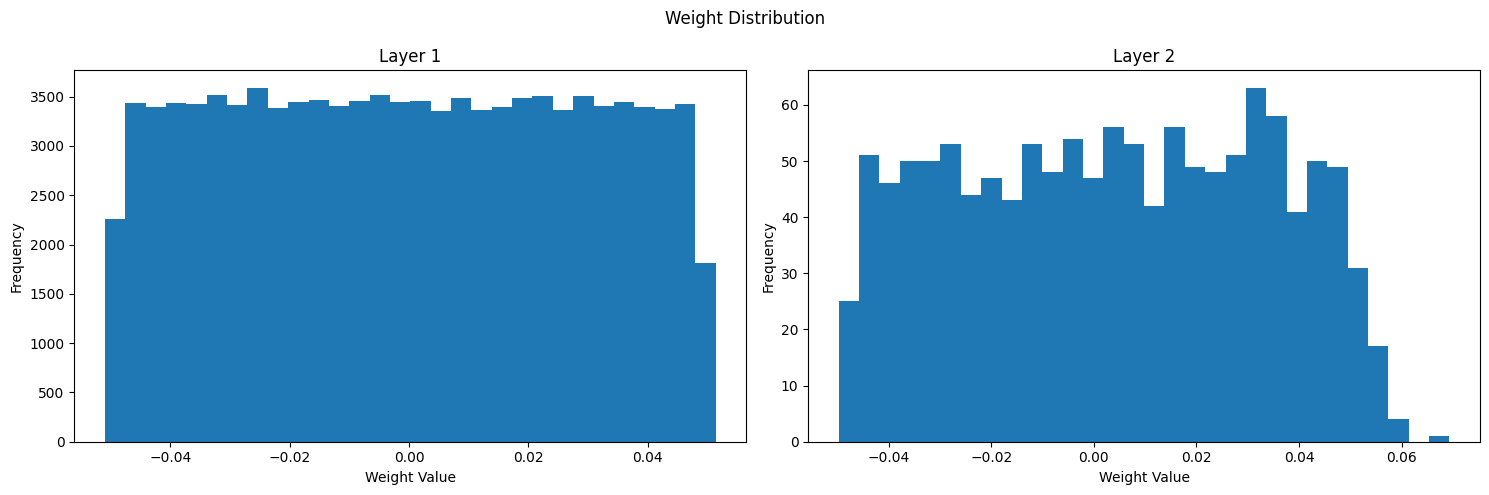


Gradient distribution for reg_L2:


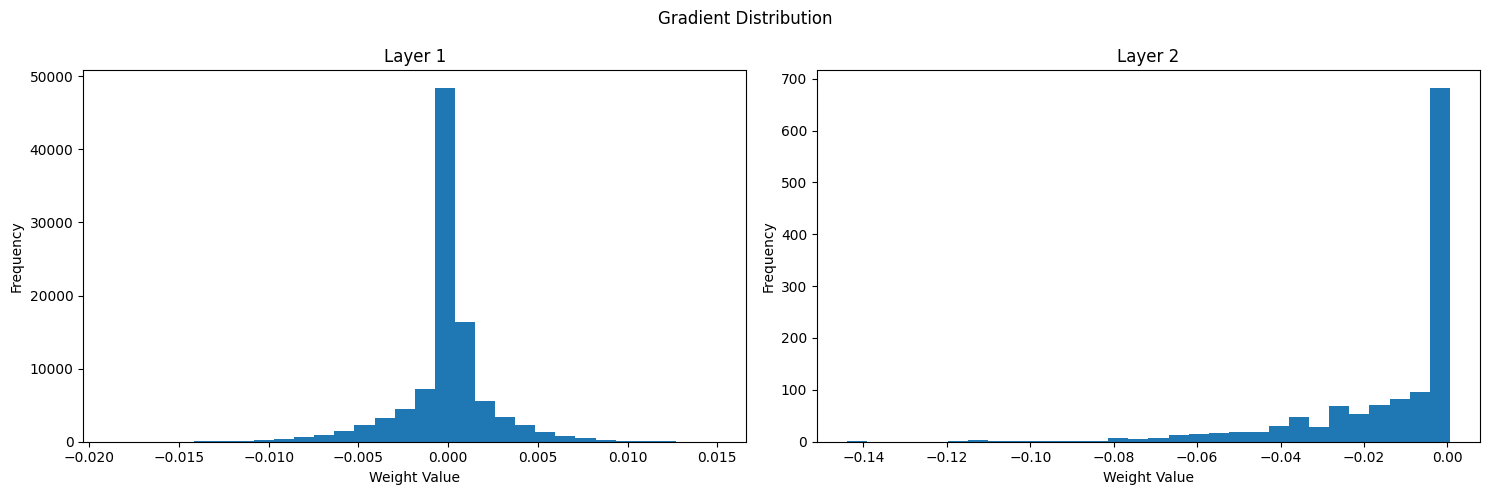

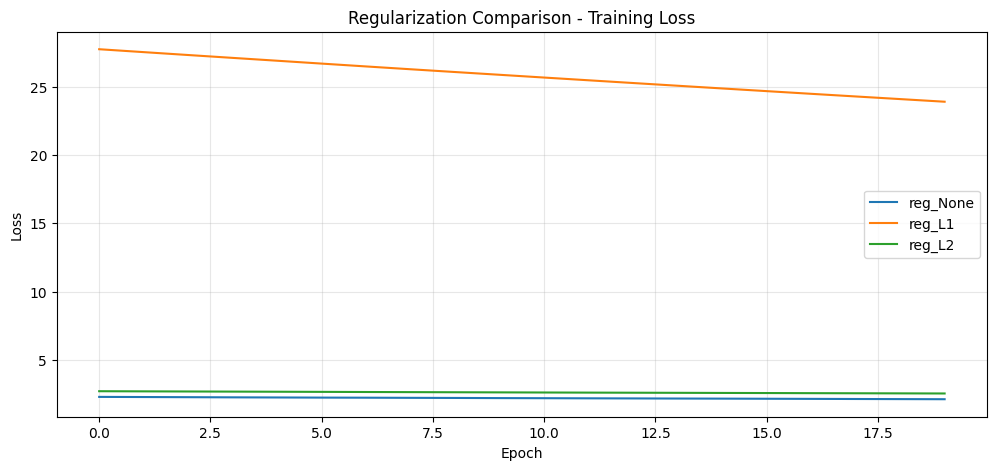

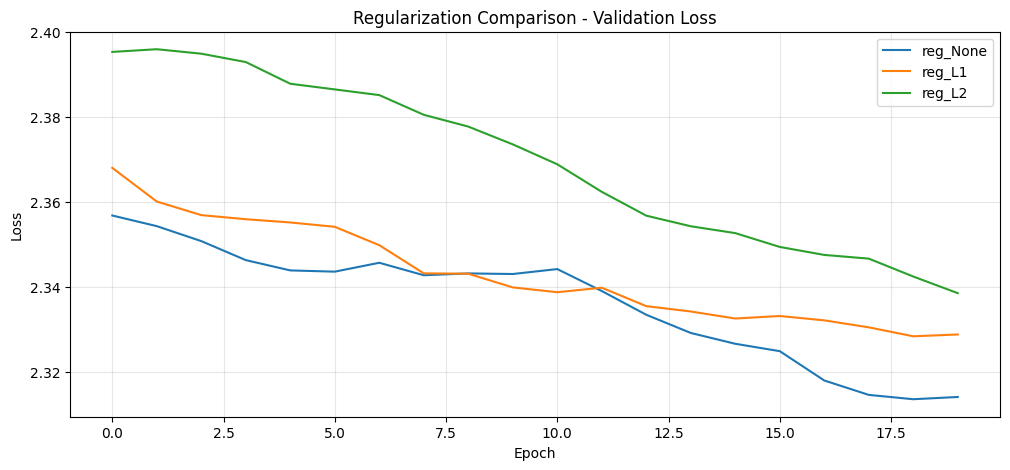

In [54]:
# Define regularizers to test
regularizers = [
    {'name': 'None', 'regularizer': None},
    {'name': 'L1', 'regularizer': 'l1'},
    {'name': 'L2', 'regularizer': 'l2'}
]

# Fixed network architecture and training parameters
fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]
fixed_lr = 0.01

# Dictionary to store models and their histories
reg_models = {}
reg_histories = {}

# Run experiments
print("\n--- Regularization Experiments ---")
for reg in regularizers:
    name = f"reg_{reg['name']}"
    
    # Create and train model
    print(f"\nTraining model with regularizer={reg['name']}")
    model = FFNN(
        layer_sizes=fixed_layer_sizes,
        activations=['relu', 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='uniform',
        regularizer=reg['regularizer']
    )
    
    # Train model with progress bar
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        # Create mini-batches
        iterator = batch_iterator(X_train, y_train_one_hot, batch_size=batch_size)
        n_batches = int(np.ceil(len(X_train) / batch_size))
        
        # Mini-batch training with progress bar
        for batch_idx, (X_batch, y_batch) in enumerate(tqdm(iterator, total=n_batches, 
                                                        desc=f'Epoch {epoch+1}/{epochs}')):
            # Forward and backward pass
            model.forward(X_batch)
            batch_loss = model.backward(y_batch)
            
            # Update weights
            model.update_weights(fixed_lr)
            
            # Accumulate loss
            epoch_loss += batch_loss * len(X_batch) / len(X_train)
        
        # Record training loss
        history['train_loss'].append(epoch_loss)
        
        # Compute validation loss
        val_pred = model.forward(X_test)
        val_loss = model.loss.compute(y_test_one_hot, val_pred)
        history['val_loss'].append(val_loss)
        
        print(f'Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}')
    
    # Store model and history
    reg_models[name] = model
    reg_histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    model.plot_gradient_distribution()

# Plot training histories
plot_comparison(reg_histories, "Regularization Comparison - Training Loss", "train_loss")
plot_comparison(reg_histories, "Regularization Comparison - Validation Loss", "val_loss")

## RMSNorm


--- Normalization Experiments ---

Training model with normalization=None


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3186 - val_loss: 2.3715


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.3091 - val_loss: 2.3656


...

Epoch 18/20 - loss: 2.1648 - val_loss: 2.3346


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.1555 - val_loss: 2.3327


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.1473 - val_loss: 2.3296

Evaluation for norm_None:
Test accuracy: 0.1000


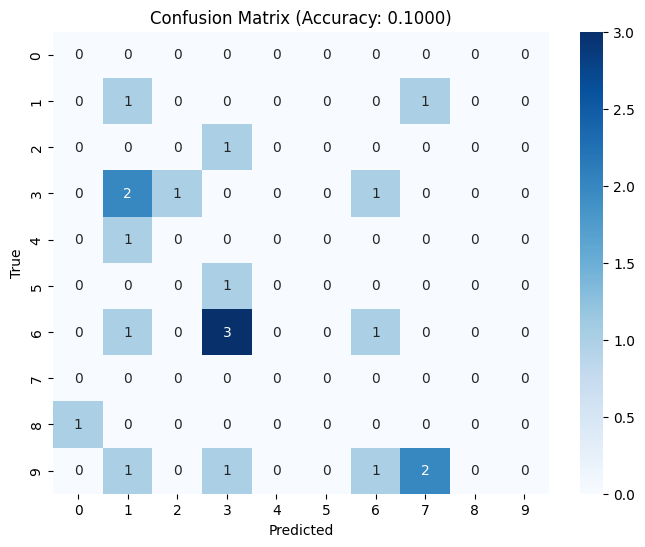


Weight distribution for norm_None:


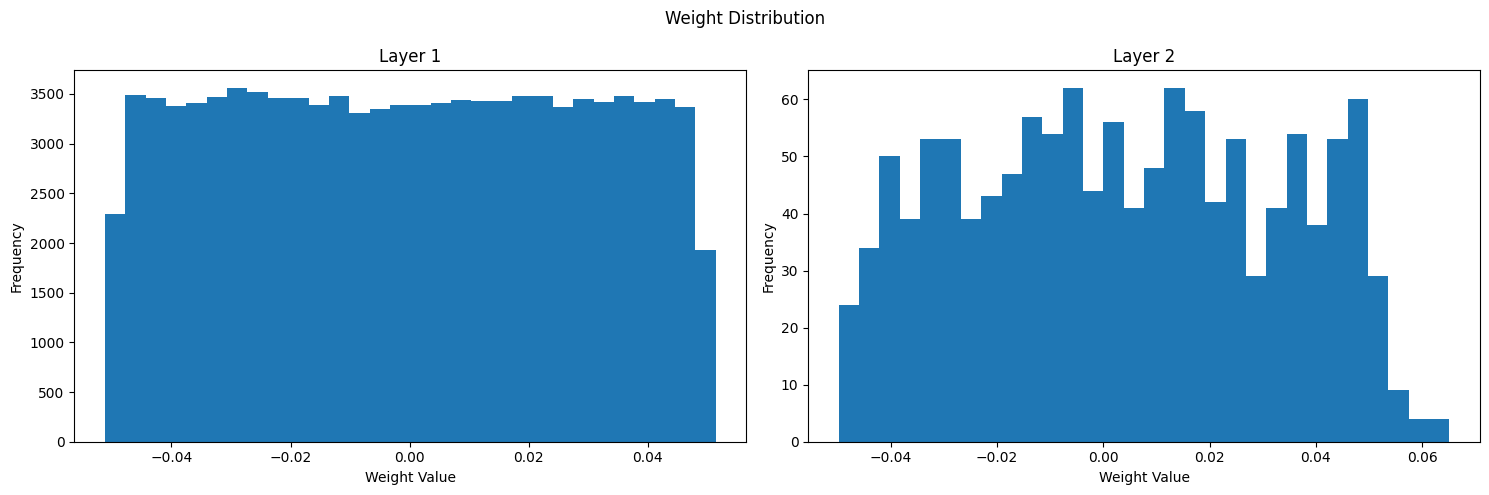


Gradient distribution for norm_None:


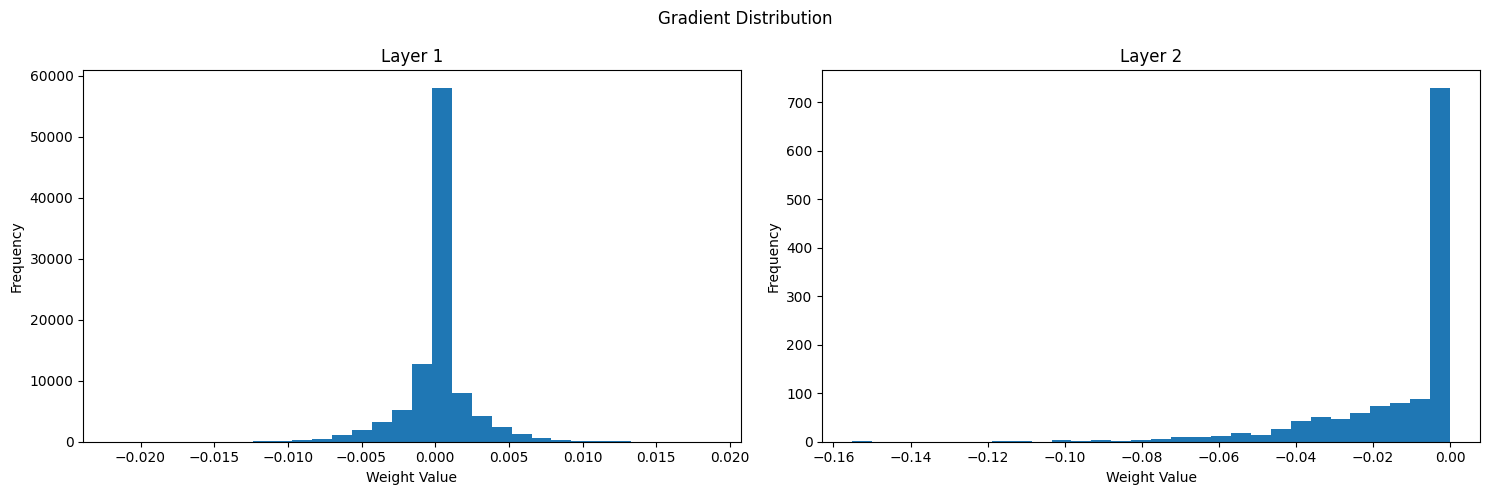


Training model with normalization=RMSNorm


Epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.6366 - val_loss: 2.4369


Epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.0394 - val_loss: 2.4522


...

Epoch 18/20 - loss: 0.7522 - val_loss: 1.7546


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 - loss: 0.7161 - val_loss: 1.7584


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 - loss: 0.6856 - val_loss: 1.7680

Evaluation for norm_RMSNorm:
Test accuracy: 0.4500


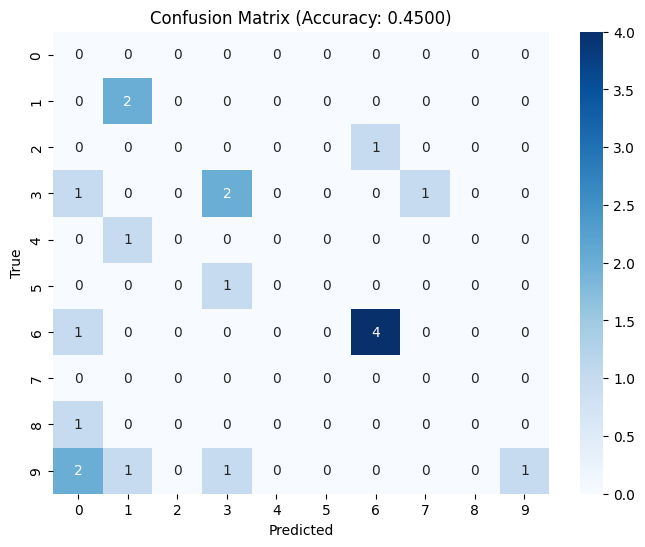


Weight distribution for norm_RMSNorm:


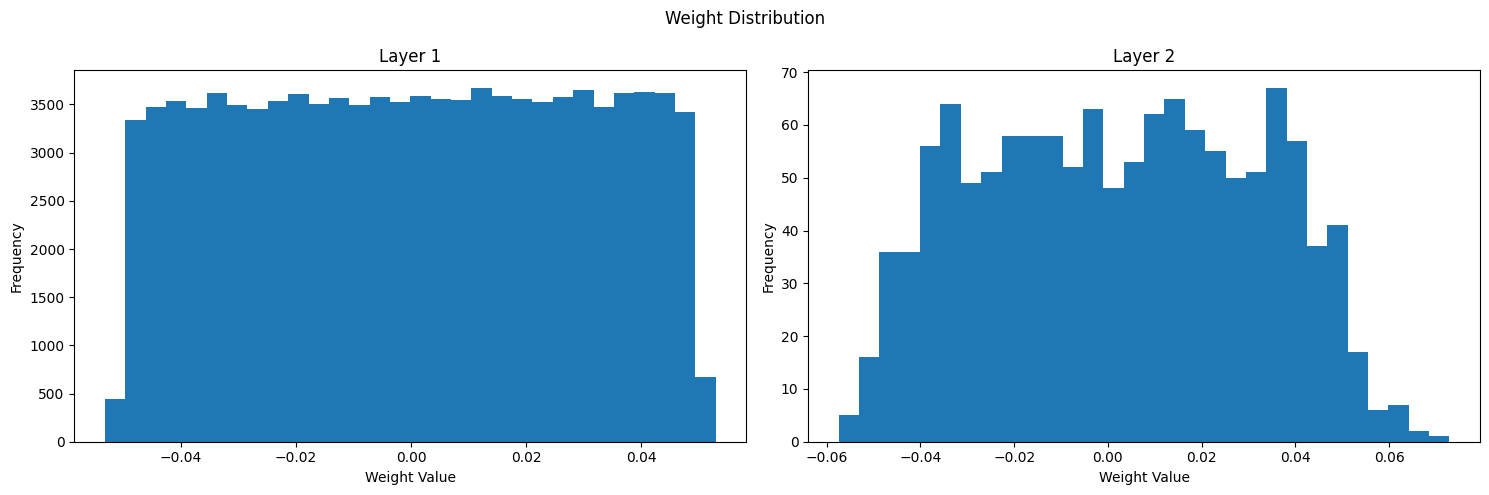


Gradient distribution for norm_RMSNorm:


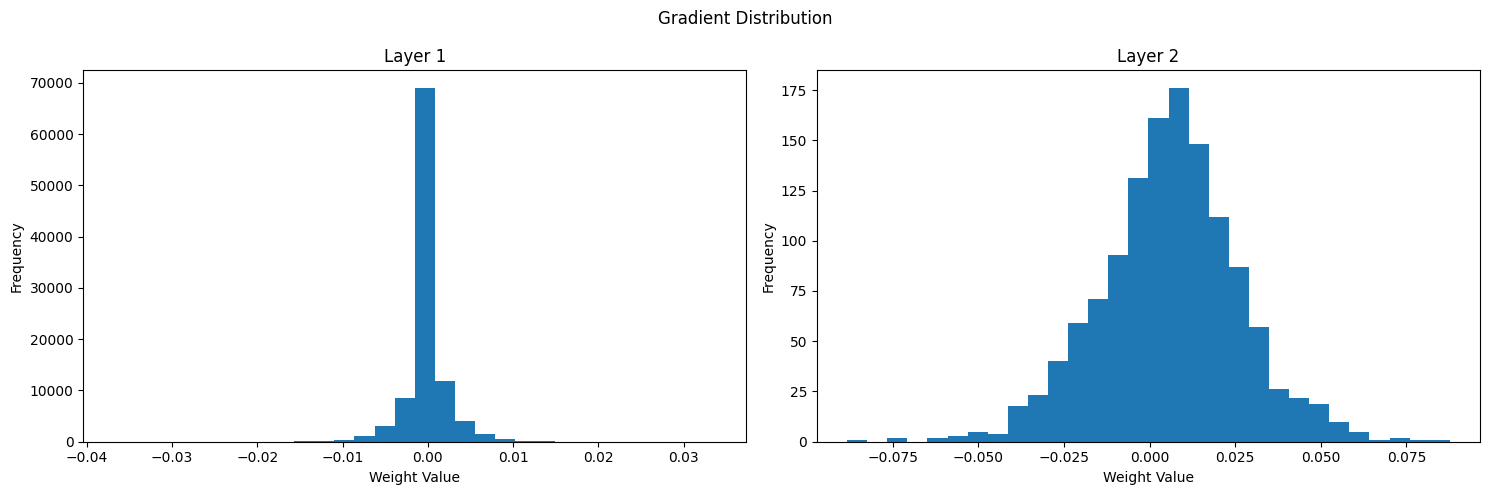

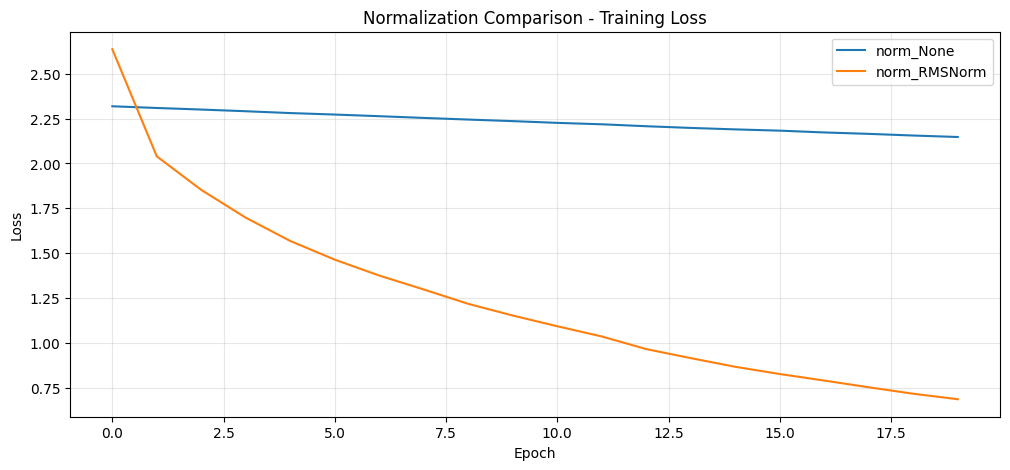

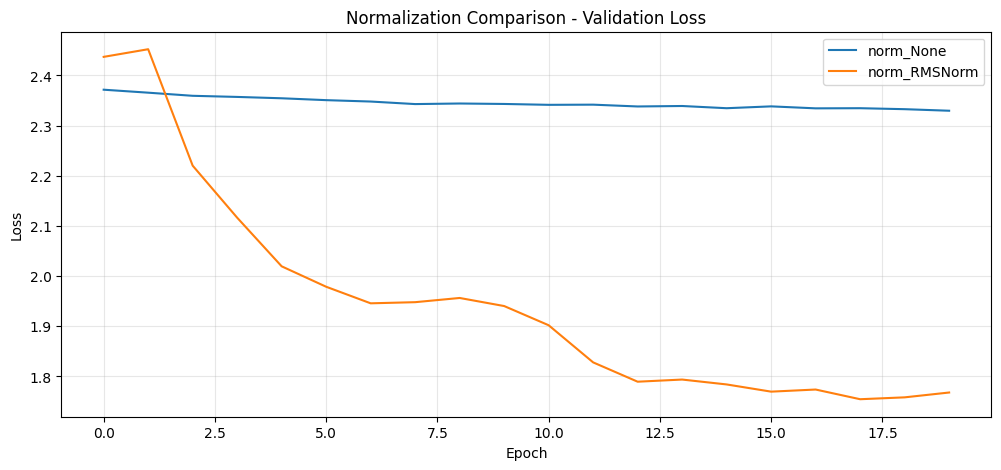

In [55]:
# Define normalization options to test
normalizations = [
    {'name': 'None', 'use_rms_norm': False},
    {'name': 'RMSNorm', 'use_rms_norm': True}
]

# Fixed network architecture and training parameters
fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]
fixed_lr = 0.01

# Dictionary to store models and their histories
norm_models = {}
norm_histories = {}

# Run experiments
print("\n--- Normalization Experiments ---")
for norm in normalizations:
    name = f"norm_{norm['name']}"
    
    # Create and train model
    print(f"\nTraining model with normalization={norm['name']}")
    model = FFNN(
        layer_sizes=fixed_layer_sizes,
        activations=['relu', 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='uniform',
        use_rms_norm=norm['use_rms_norm']
    )
    
    # Train model with progress bar
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        # Create mini-batches
        iterator = batch_iterator(X_train, y_train_one_hot, batch_size=batch_size)
        n_batches = int(np.ceil(len(X_train) / batch_size))
        
        # Mini-batch training with progress bar
        for batch_idx, (X_batch, y_batch) in enumerate(tqdm(iterator, total=n_batches, 
                                                        desc=f'Epoch {epoch+1}/{epochs}')):
            # Forward and backward pass
            model.forward(X_batch)
            batch_loss = model.backward(y_batch)
            
            # Update weights
            model.update_weights(fixed_lr)
            
            # Accumulate loss
            epoch_loss += batch_loss * len(X_batch) / len(X_train)
        
        # Record training loss
        history['train_loss'].append(epoch_loss)
        
        # Compute validation loss
        val_pred = model.forward(X_test)
        val_loss = model.loss.compute(y_test_one_hot, val_pred)
        history['val_loss'].append(val_loss)
        
        print(f'Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}')
    
    # Store model and history
    norm_models[name] = model
    norm_histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    model.plot_gradient_distribution()

# Plot training histories
plot_comparison(norm_histories, "Normalization Comparison - Training Loss", "train_loss")
plot_comparison(norm_histories, "Normalization Comparison - Validation Loss", "val_loss")

# 1. **Depth and Width**: BAGUS OR NO
# 2. **Activation Functions**: BAGUS OR NO
# 3. **Learning Rate**: BAGUS OR NO
# 4. **Weight Initialization**: BAGUS OR NO
# 5. **Comparison with sklearn**: BAGUS OR NO
# 6. **Regularization (Bonus)**: BAGUS OR NO
# 7. **RMSNorm (Bonus)**: BAGUS OR NO